# Empirical Fourier Decomposition (EFD)

**EFD** (Zhou, Feng, Xu, Wang & Lv, 2022) is an *adaptive Fourier-spectrum*
method: it partitions $|X(\omega)|$ on $[0,\pi]$ and extracts each band with an
**ideal (brick-wall, zero-phase) filter**.  There is no sifting loop, so EFD is
algorithmically closer to the **Empirical Wavelet Transform (EWT)** than to
classical **EMD**.

| | EMD | EWT | EFD |
|---|---|---|---|
| Domain | time (sifting) | Fourier spectrum | Fourier spectrum |
| Filter | spline envelopes | Meyer wavelets (transition bands, tight frame) | ideal rectangular filters (no transition phase) |
| Modes | data-driven, variable count | prescribed $K$ | prescribed $N$ |
| Typical issue | mode mixing / over-sift | Meyer leakage between close peaks | shared boundary bins; needs a good $N$ |

The PySDKit class `EFD` is a faithful port of the MATLAB toolbox
(`EFD.m`, `Segm_tec.m`, `plotbounds.m`, `IFIA.m`; File Exchange 97747).

**References**

> W. Zhou, Z. Feng, Y. F. Xu, X. Wang, H. Lv.
> *Empirical Fourier decomposition: An accurate signal decomposition method for
> nonlinear and non-stationary time series analysis.*
> Mechanical Systems and Signal Processing, 163:108155, 2022.
> https://doi.org/10.1016/j.ymssp.2021.108155

ArXiv preprint: [1912.00414](https://arxiv.org/abs/1912.00414).
MATLAB toolbox: [File Exchange 97747](https://www.mathworks.com/matlabcentral/fileexchange/97747-empirical-fourier-decomposition-efd).


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import EFD, EWT, efd
from pysdkit._ewt.efd import plot_bounds, ifia
from pysdkit.plot import plot_IMFs, plot_IMFs_amplitude_spectra
import pysdkit

print("pysdkit from:", pysdkit.__file__)
print(EFD())

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py
Empirical Fourier Decomposition (EFD)


## 2. Algorithm principles

EFD is described as a *partial combination* of EWT (spectrum segmentation)
and the Fourier Decomposition Method (FDM / FIBFs).  Figure 2 of the paper
is a bank of brick-wall band-pass filters on $[0,\pi]$.

### 2.1 Improved segmentation (`Segm_tec`)

The one-sided magnitude spectrum $f(\omega)=|X(\omega)|$, $\omega\in[0,\pi]$,
is partitioned into $N$ bands ($N+1$ boundaries).  Control points are the
**local maxima** of $f$ (the DC and Nyquist bins are always treated as
maxima, as in MATLAB).  They are sorted by height:

1. if at least $N$ maxima exist, keep the $N$ largest and re-order them by
   frequency;
2. otherwise keep all of them and reset $N$.

Let $\tilde\omega_i$ be those peak locations, with $\tilde\omega_0=0$ and
$\tilde\omega_N=\pi$ in the continuous picture.  Each **boundary** is the
*global minimum of $f$ between consecutive peaks* (paper Eq. (10)):

$$
\Omega_n=\arg\min_{\omega\in[\tilde\omega_{n-1},\,\tilde\omega_n]} f(\omega),
\qquad n=1,\ldots,N,
$$

together with the spectrum ends.  Central frequencies `cerf` are the retained
peak locations mapped to $[0,\pi]$.

This differs from Gilles' EWT local-maxima rule, which places a boundary at
the *midpoint* between two maxima and therefore tends to cut a wide or
flat-topped mode in the wrong place.  EFD's min-between-maxima rule hugs the
trough, which the paper shows is more robust for low-frequency energy,
wideband modes, and high-frequency noise (Fig. 3).

### 2.2 Ideal filter bank (continuous EFD)

After the boundaries $\omega_n$ are known, each Fourier-intrinsic band
function (FIBF) is the inverse Fourier transform of the spectrum restricted
to $[\omega_n,\omega_{n+1}]$ (and the conjugate negative frequencies).  In
the continuous setting the analytic FIBF is (paper Eq. (16))

$$
A_i(t)\,e^{j\theta_i(t)}
=\sum_{n:\,\omega_n\le n\varphi_0<\omega_{n+1}} c_n\,e^{jn\varphi_0 t}.
$$

There is **no Meyer transition** $\gamma$ and **no tight-frame constraint**.
The filters are therefore *zero-phase* and do not leak energy across a
transition band — the main practical difference versus EWT.

### 2.3 Discrete implementation (`EFD.m`)

For a length-$K$ real sequence $x[n]$:

1. FFT $\to$ one-sided $|X[k]|$, $k=0,\ldots,\mathrm{round}(K/2)-1$.
2. `Segm_tec` $\to$ bin boundaries, then scale to radians,
   $\omega=\pi\cdot\mathrm{bin}/\mathrm{round}(K/2)$.
3. **Mirror extension** (MATLAB): with $\ell=\mathrm{round}(K/2)$,
   $$
   x_{\mathrm{ext}}
   =\bigl[x[\ell-1],\ldots,x[1],\; x,\; x[K],\ldots,x[K-\ell+1]\bigr]
   $$
   (1-based).  This is *not* the symmetric `fmirror` used elsewhere in
   PySDKit: the right pad has $\ell$ samples, the left pad $\ell-1$.
   Odd-length records are kept.
4. Re-map boundaries onto the extended FFT and copy each ideal band,
   including the Hermitian negative-frequency bins.  Adjacent bands
   **share** the boundary bin (MATLAB's inclusive `a:b`).
5. IFFT and crop back to length $K$.

Hilbert instantaneous amplitude / frequency of each FIBF (paper §3.4,
MATLAB `IFIA.m`) gives a time–frequency representation analogous to HHT.

### 2.4 Why this lives next to EWT

Both methods (i) detect boundaries on $|X(\omega)|$ and (ii) apply a Fourier
filter bank.  EMD instead iterates envelope means in time.  EFD's filters
are rectangular rather than Meyer, so PySDKit ships it under `pysdkit._ewt`.


## 3. Paper numerical studies

Section 4 of Zhou *et al.* uses four synthetic signals plus an ECG.  All
synthetic records live on $t\in[0,1]$ with $f_s=1000\,\mathrm{Hz}$
(`t = 0:1/fs:1` in MATLAB, 1001 samples).  The number of EFD segments is
set to **4, 5, 3, 4** for Examples 1–4.  The cells below reproduce
Examples 1–3 (non-stationary multimode signals, originally from the EWT /
VMD literature) and Example 4 (closely spaced structural modes).


### 3.1 Example 1 — linear trend and two harmonics (Eq. 22)

$$
\begin{aligned}
f_{11}(t)&=6t,\\
f_{12}(t)&=2\cos(8\pi t),\\
f_{13}(t)&=\cos(40\pi t),\\
f_1(t)&=f_{11}(t)+f_{12}(t)+f_{13}(t).
\end{aligned}
$$

The paper uses **4** EFD segments (one extra band near Nyquist).  The first
three modes should recover a trend, a 4 Hz tone and a 20 Hz tone.


f1 length: 1001
IMF shape: (4, 1001)
central frequencies (rad): [0.0063 0.0314 0.1317 3.1416]
boundaries (rad): [0.     0.0188 0.1191 3.1353 3.1353]


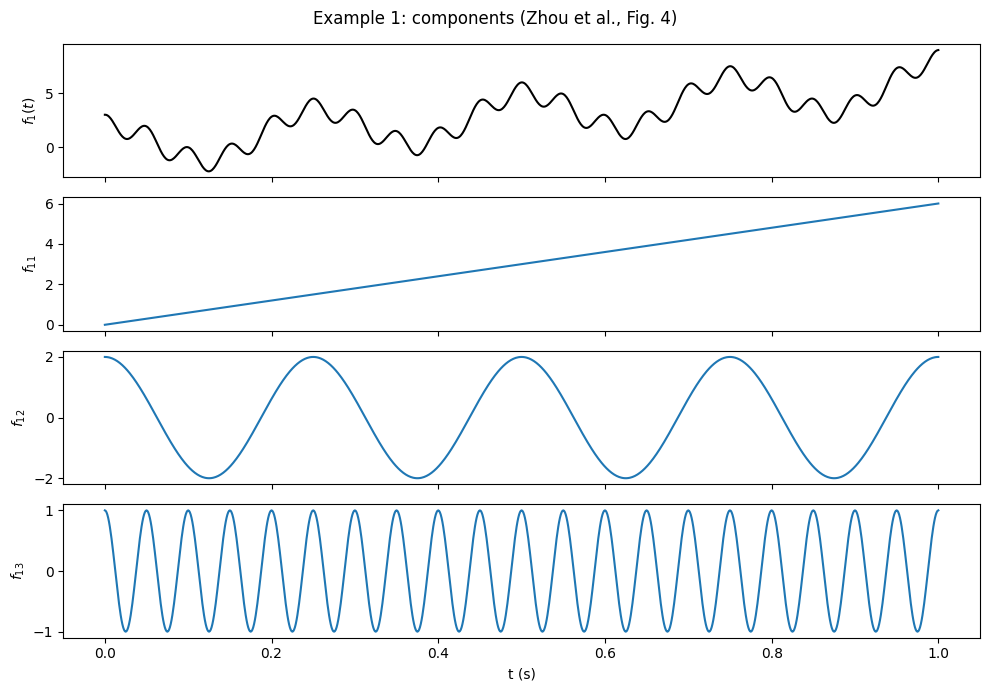

In [2]:
fs = 1000.0
t = np.arange(0.0, 1.0 + 1.0 / fs, 1.0 / fs)

f11 = 6.0 * t
f12 = 2.0 * np.cos(8.0 * np.pi * t)
f13 = np.cos(40.0 * np.pi * t)
f1 = f11 + f12 + f13

efd_1 = EFD(max_imfs=4)
imfs_1, cerf_1, bounds_1 = efd_1.fit_transform(f1, return_all=True)

print("f1 length:", f1.size)
print("IMF shape:", imfs_1.shape)
print("central frequencies (rad):", np.round(cerf_1, 4))
print("boundaries (rad):", np.round(bounds_1, 4))

fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
axes[0].plot(t, f1, color="k")
axes[0].set_ylabel(r"$f_1(t)$")
for ax, y, lab in zip(
    axes[1:], (f11, f12, f13), (r"$f_{11}$", r"$f_{12}$", r"$f_{13}$")
):
    ax.plot(t, y)
    ax.set_ylabel(lab)
axes[-1].set_xlabel("t (s)")
fig.suptitle("Example 1: components (Zhou et al., Fig. 4)")
fig.tight_layout()
plt.show()

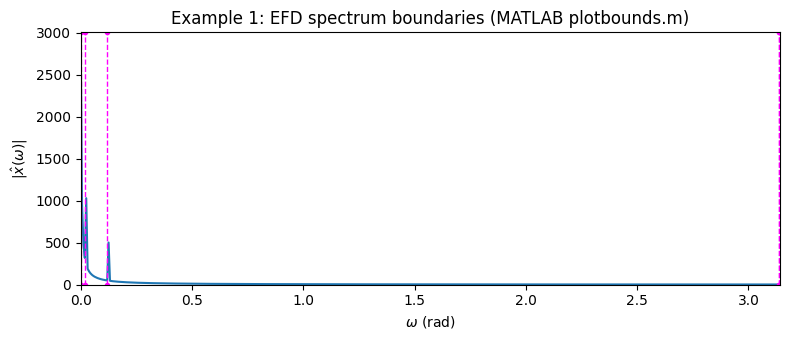

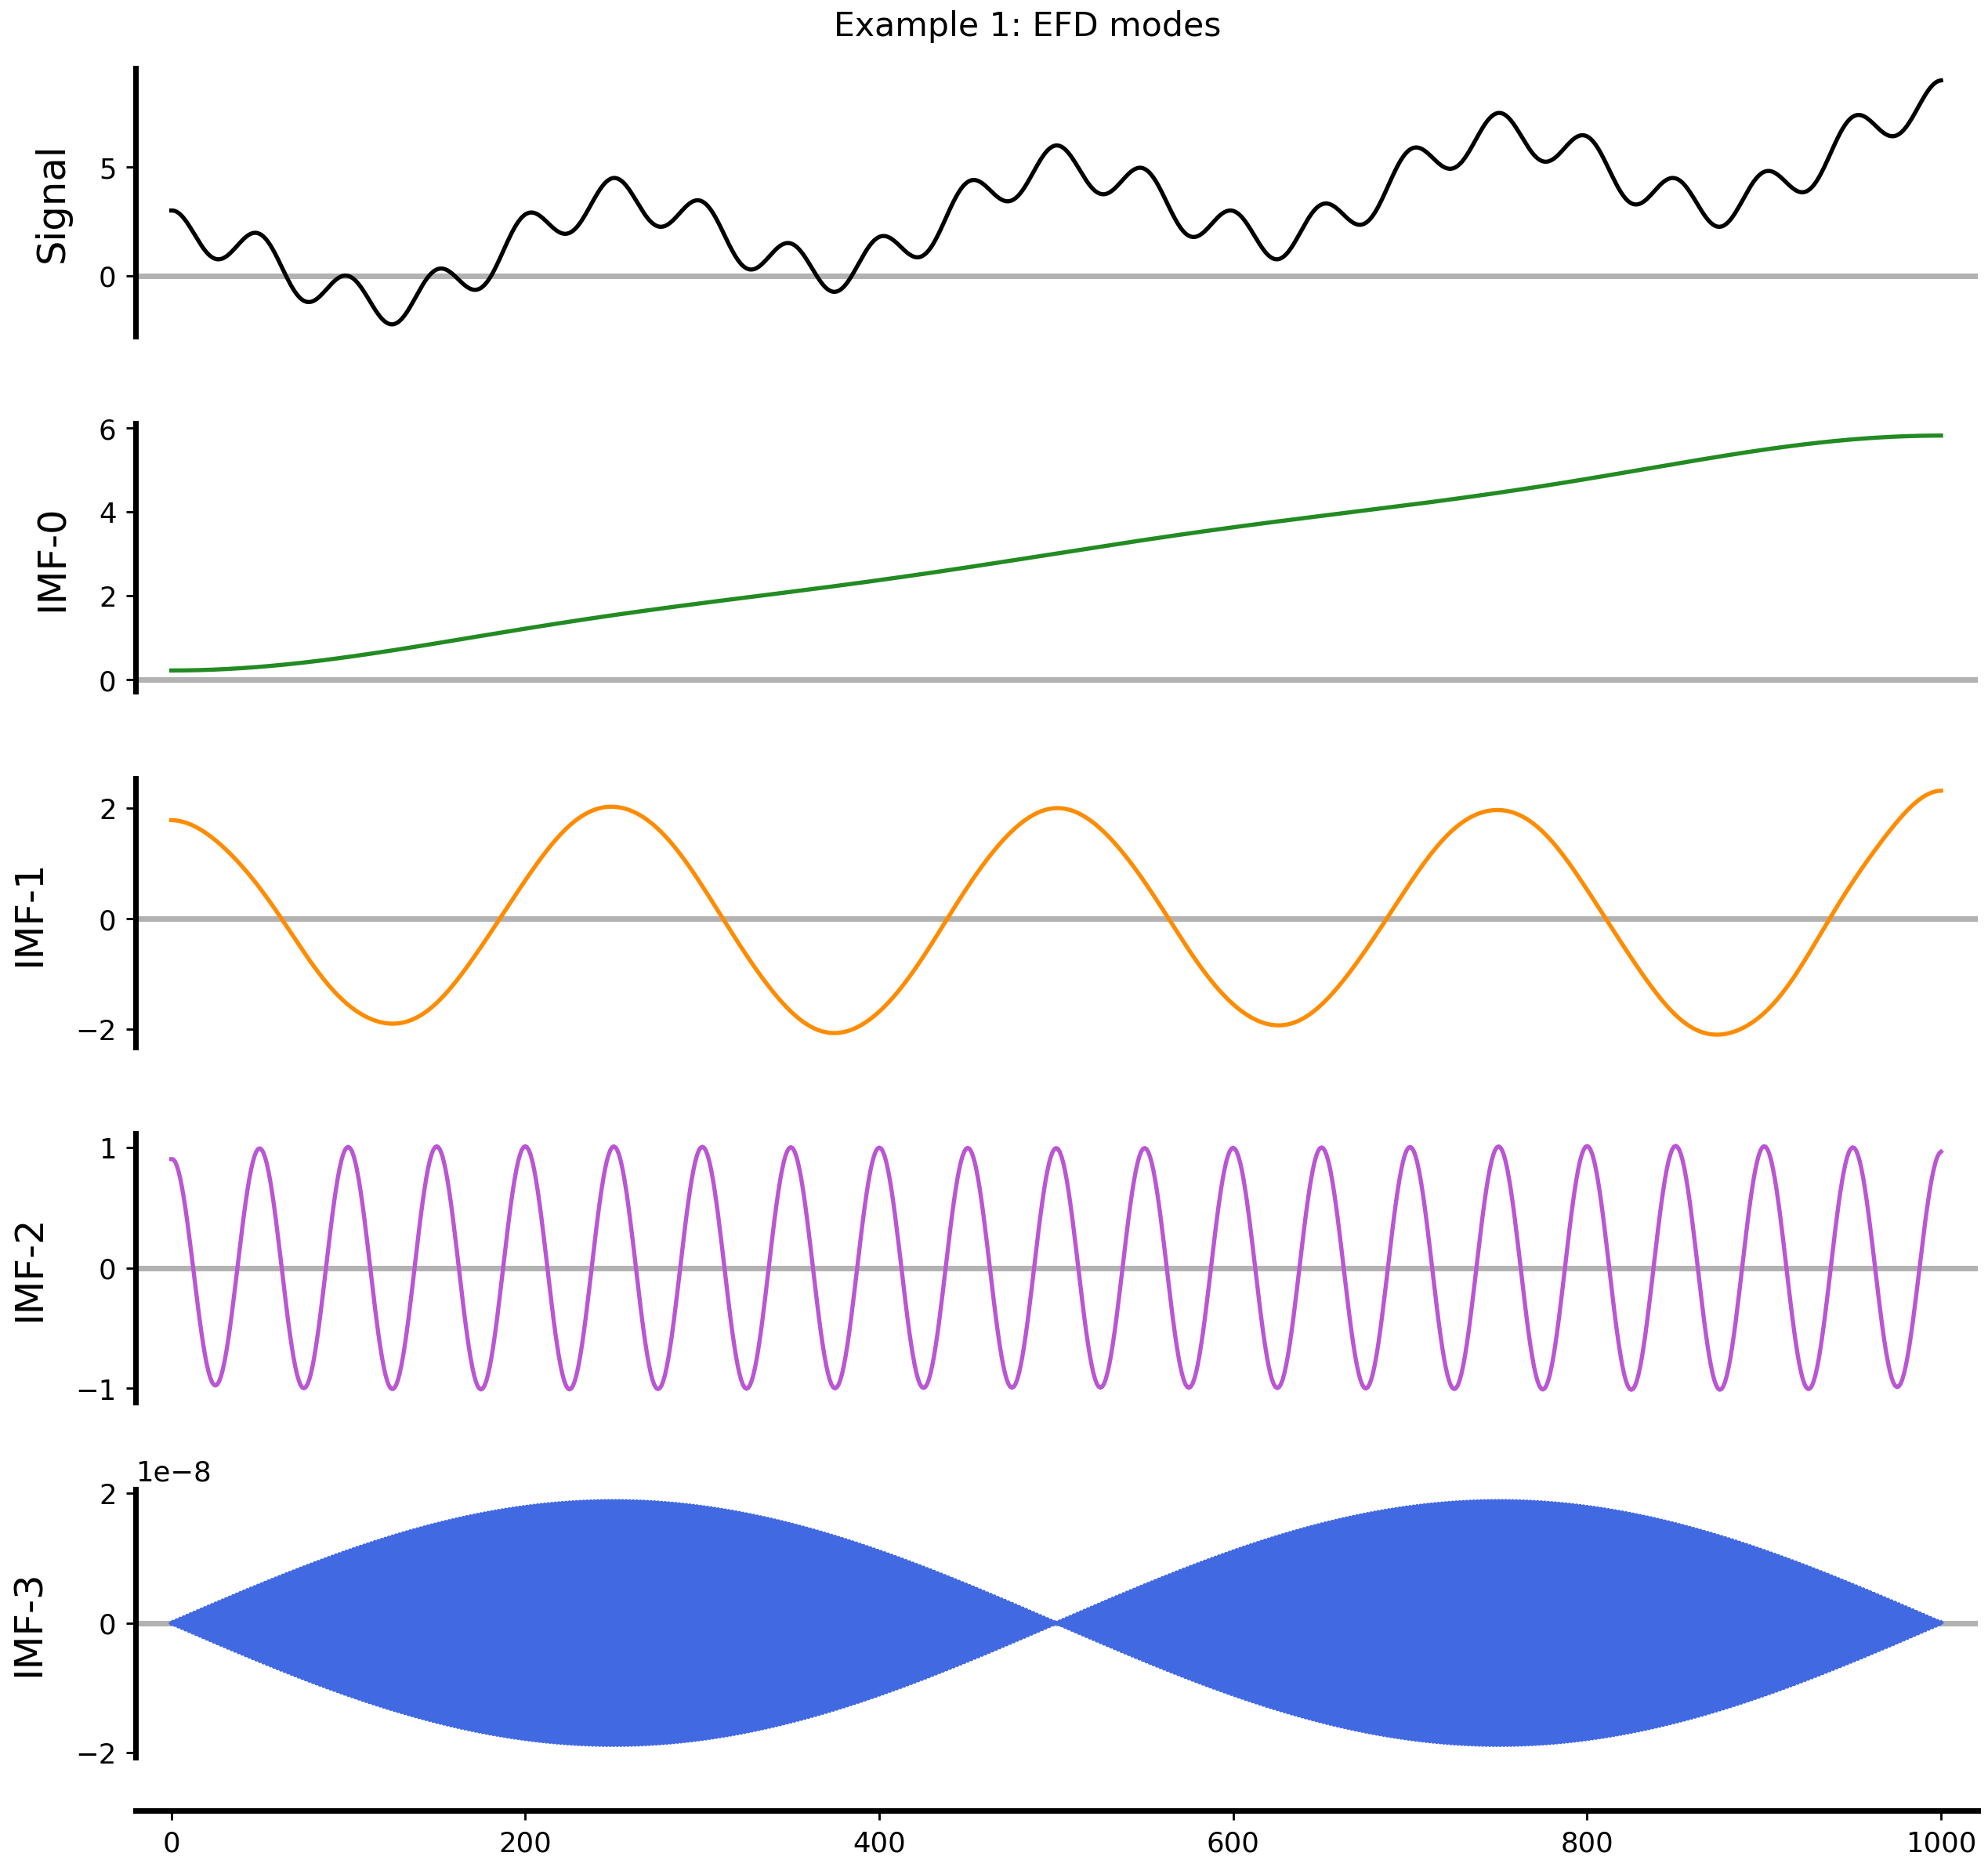

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.5))
plot_bounds(f1, bounds_1, ax=ax)
ax.set_title("Example 1: EFD spectrum boundaries (MATLAB plotbounds.m)")
fig.tight_layout()
plt.show()

plot_IMFs(f1, imfs_1, fs=fs)
plt.gcf().suptitle("Example 1: EFD modes", y=1.01)
plt.show()

The MATLAB `__main__` / File Exchange demo uses the same $f_1$ with $N=3$.
That setting matches the three physical components exactly; we show it next
to EWT ($K=3$) so the Meyer transition leakage on the trend (paper Fig. 6)
is visible.


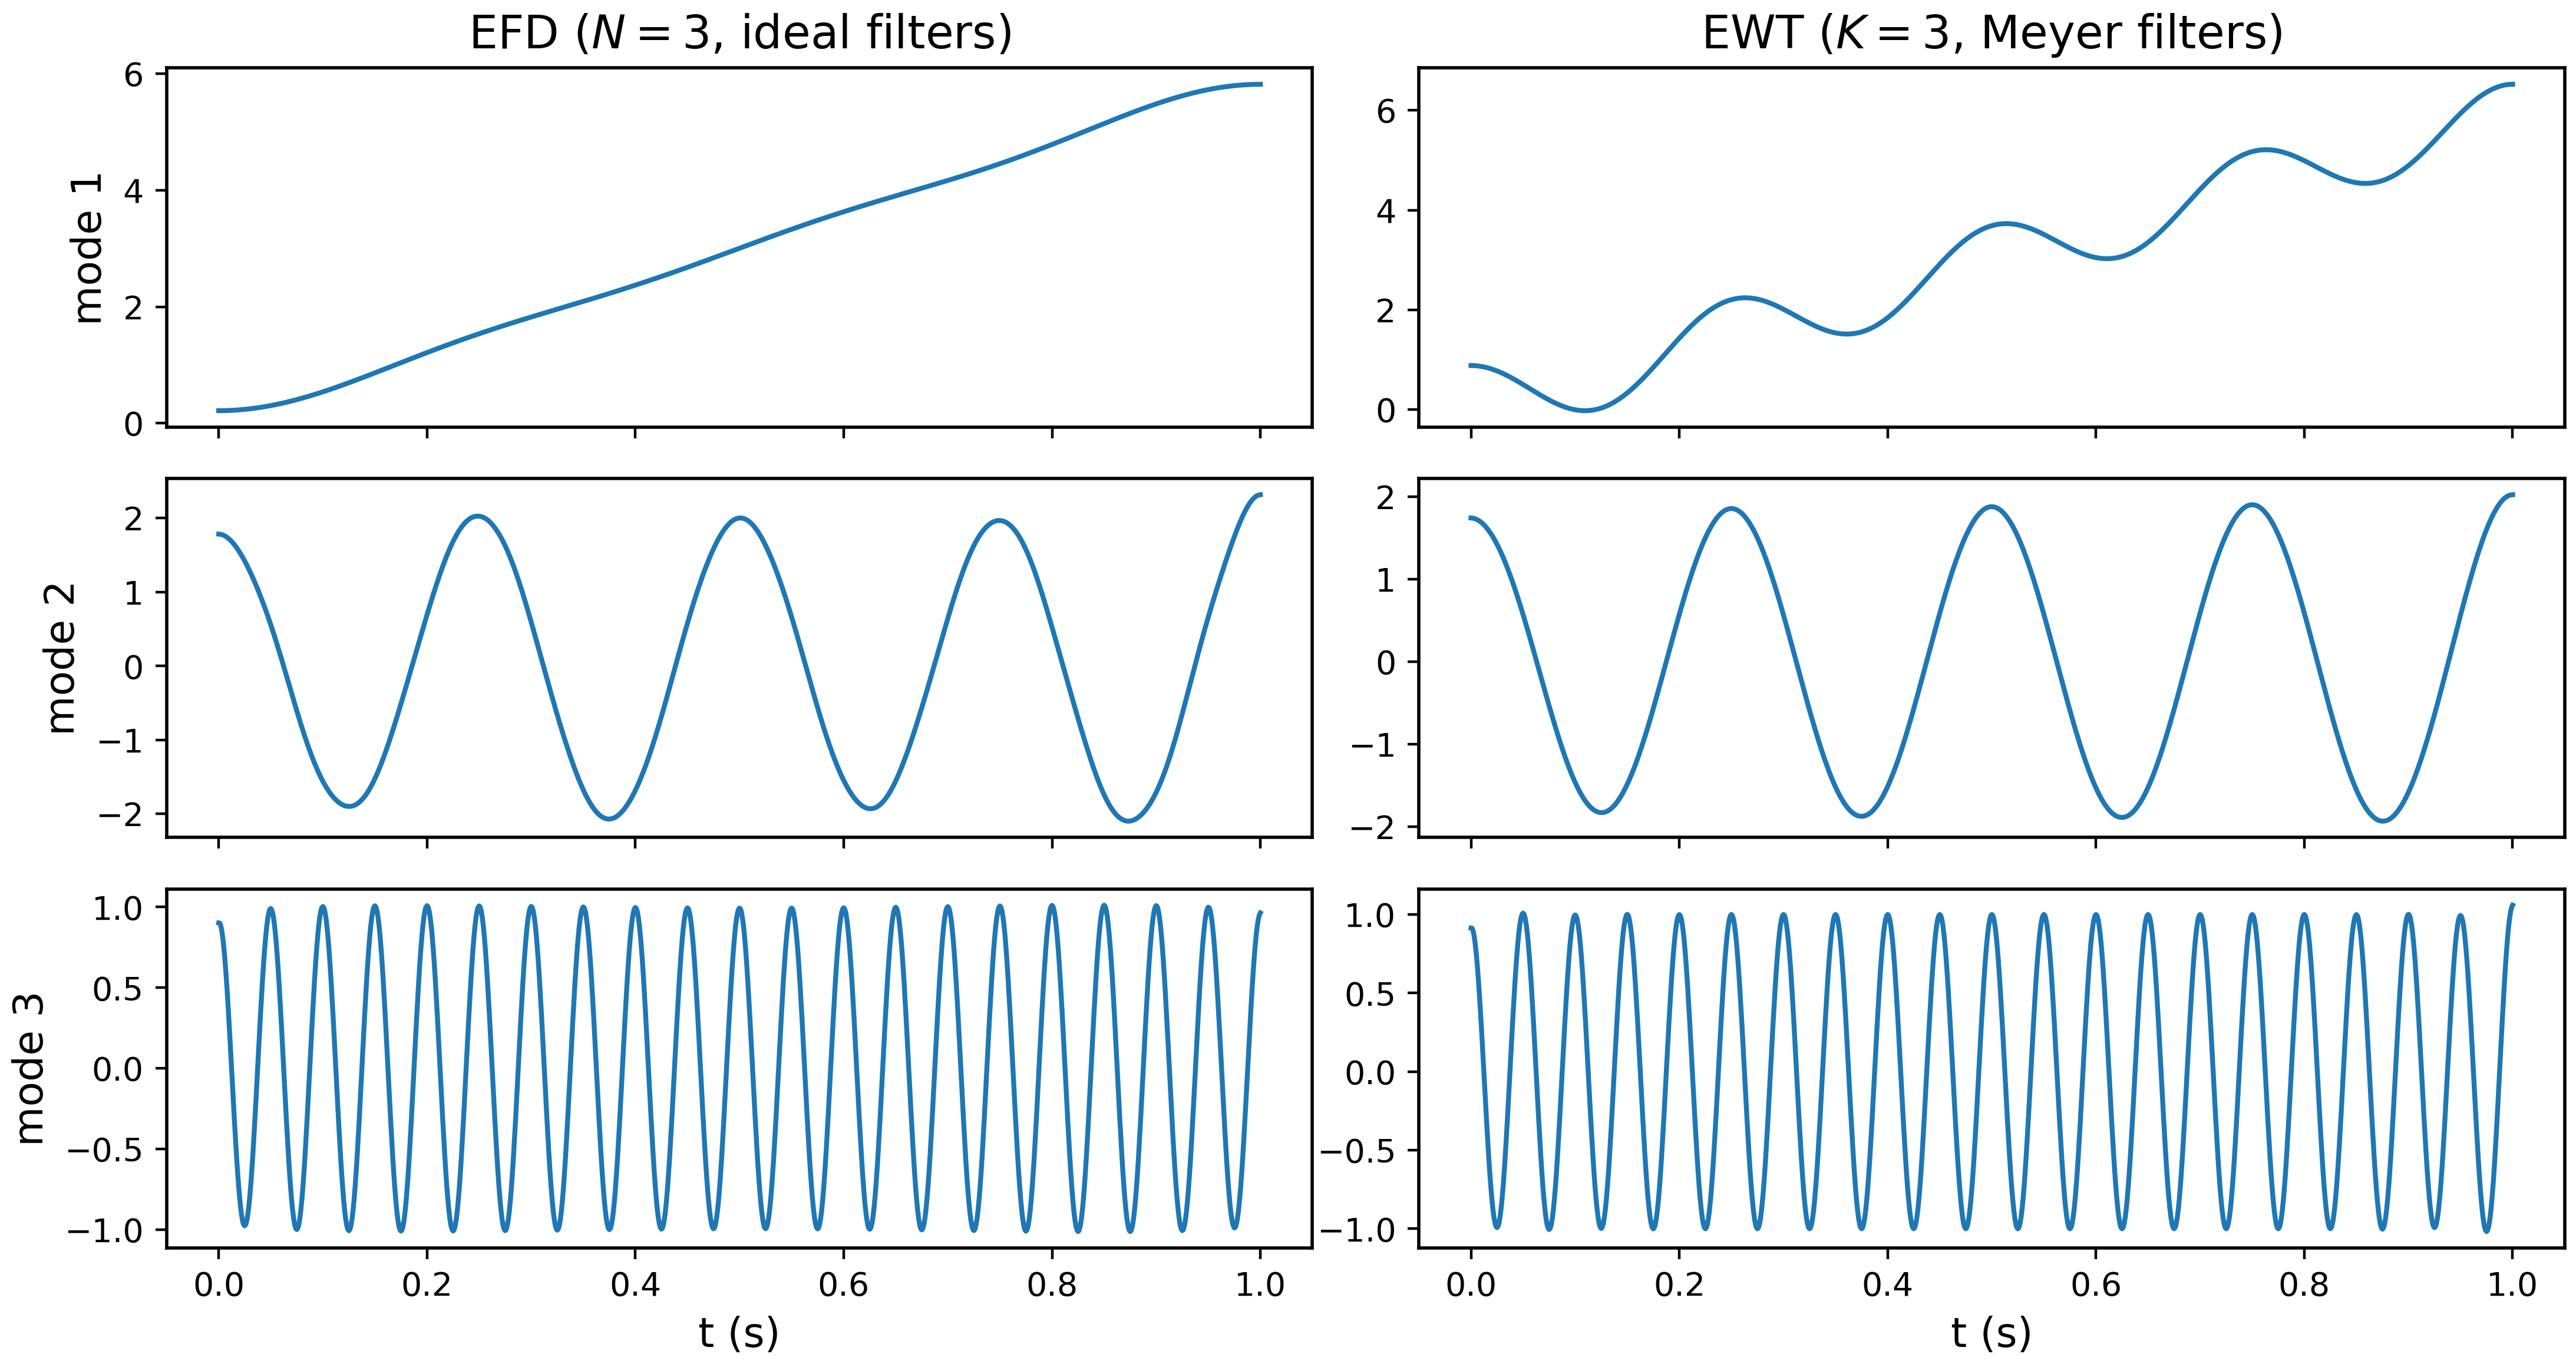

EFD |corr| vs true components (best match per IMF):
  trend   1.000
  4 Hz    0.998
  20 Hz   1.000


In [4]:
imfs_efd3 = EFD(max_imfs=3).fit_transform(f1)
imfs_ewt = EWT(K=3, detect="locmax").fit_transform(f1)

fig, axes = plt.subplots(3, 2, figsize=(11, 6), sharex=True)
for k in range(3):
    axes[k, 0].plot(t, imfs_efd3[k])
    axes[k, 1].plot(t, imfs_ewt[k])
    axes[k, 0].set_ylabel(f"mode {k + 1}")
axes[0, 0].set_title("EFD ($N=3$, ideal filters)")
axes[0, 1].set_title("EWT ($K=3$, Meyer filters)")
axes[-1, 0].set_xlabel("t (s)")
axes[-1, 1].set_xlabel("t (s)")
fig.tight_layout()
plt.show()

print("EFD |corr| vs true components (best match per IMF):")
truth = (f11, f12, f13)
for name, y in zip(("trend", "4 Hz", "20 Hz"), truth):
    c = [abs(np.corrcoef(imfs_efd3[k], y)[0, 1]) for k in range(3)]
    print(f"  {name:6s}  {max(c):.3f}")

### 3.2 Example 2 — quadratic trend, linear chirp, piecewise harmonic (Eq. 23)

$$
\begin{aligned}
f_{21}(t)&=6t^{2},\\
f_{22}(t)&=\cos(8\pi t+15\pi t^{2}),\\
f_{23}(t)&=\begin{cases}
\cos(80\pi t), & 0\le t\le 0.5,\\
\cos(60\pi t), & \text{otherwise},
\end{cases}\\
f_2(t)&=f_{21}(t)+f_{22}(t)+f_{23}(t).
\end{aligned}
$$

$f_{23}$ occupies two well-separated spectral peaks (40 Hz then 30 Hz), so
EFD / EWT split it into **two** modes; the paper therefore uses **5**
segments (trend, chirp, two piecewise tones, leftover).  FDM kept $f_{23}$
as a single FIBF.


IMF shape: (5, 1001)
boundaries (rad): [0.     0.0439 0.0878 0.1442 0.2383 0.2947]


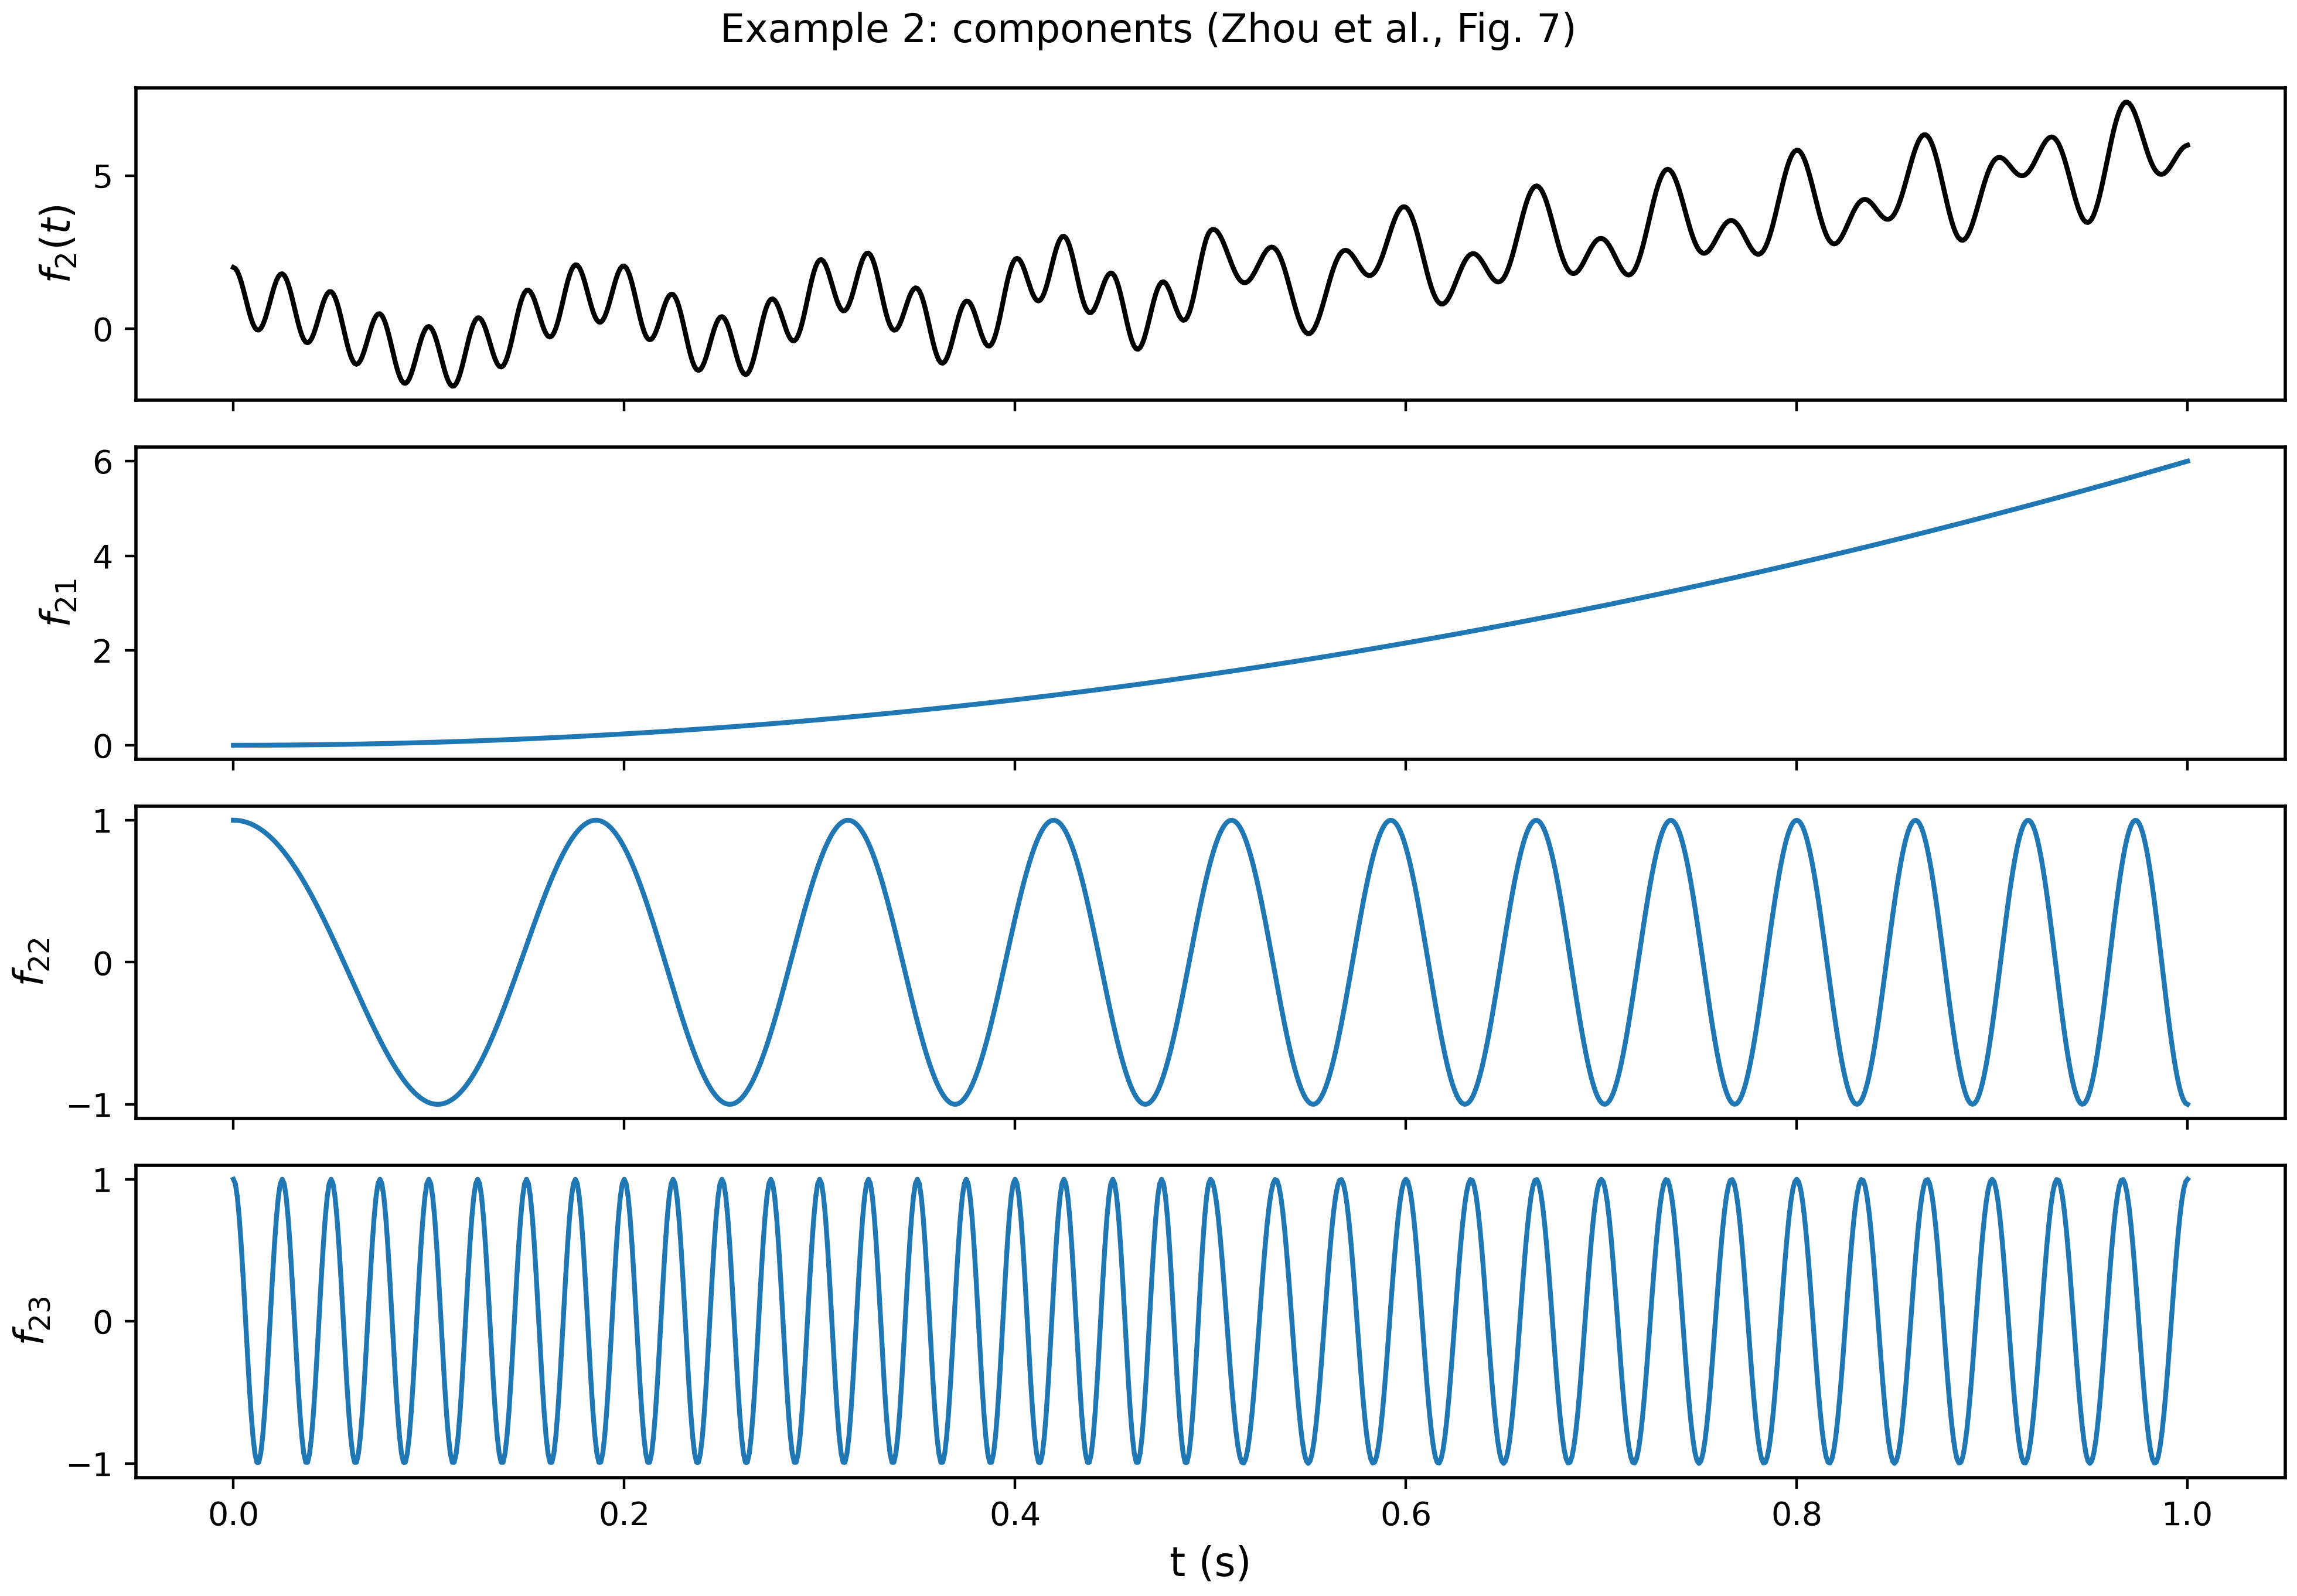

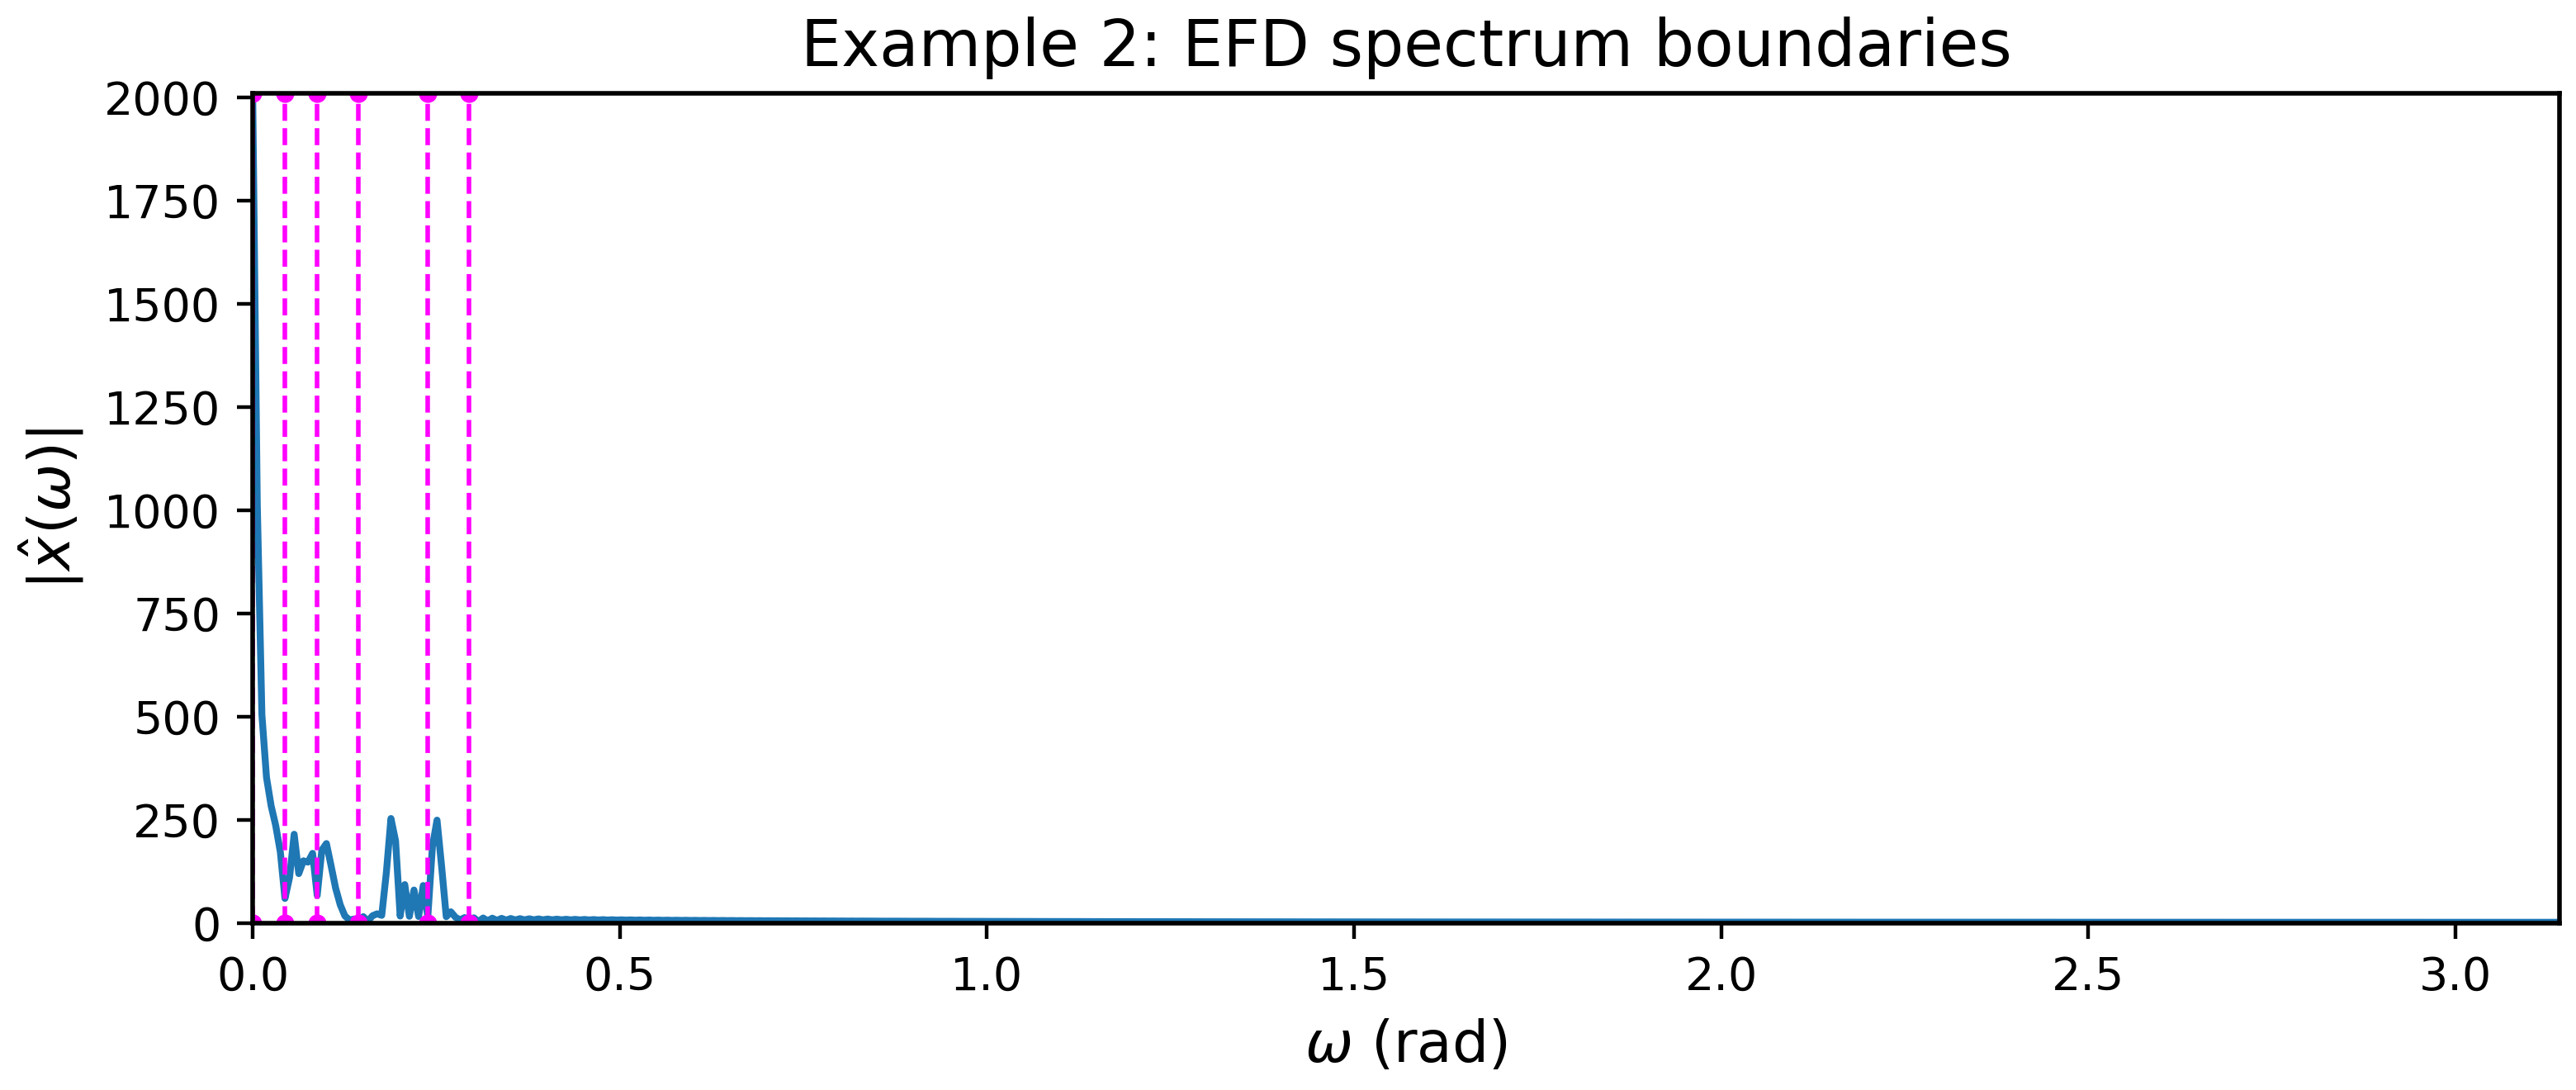

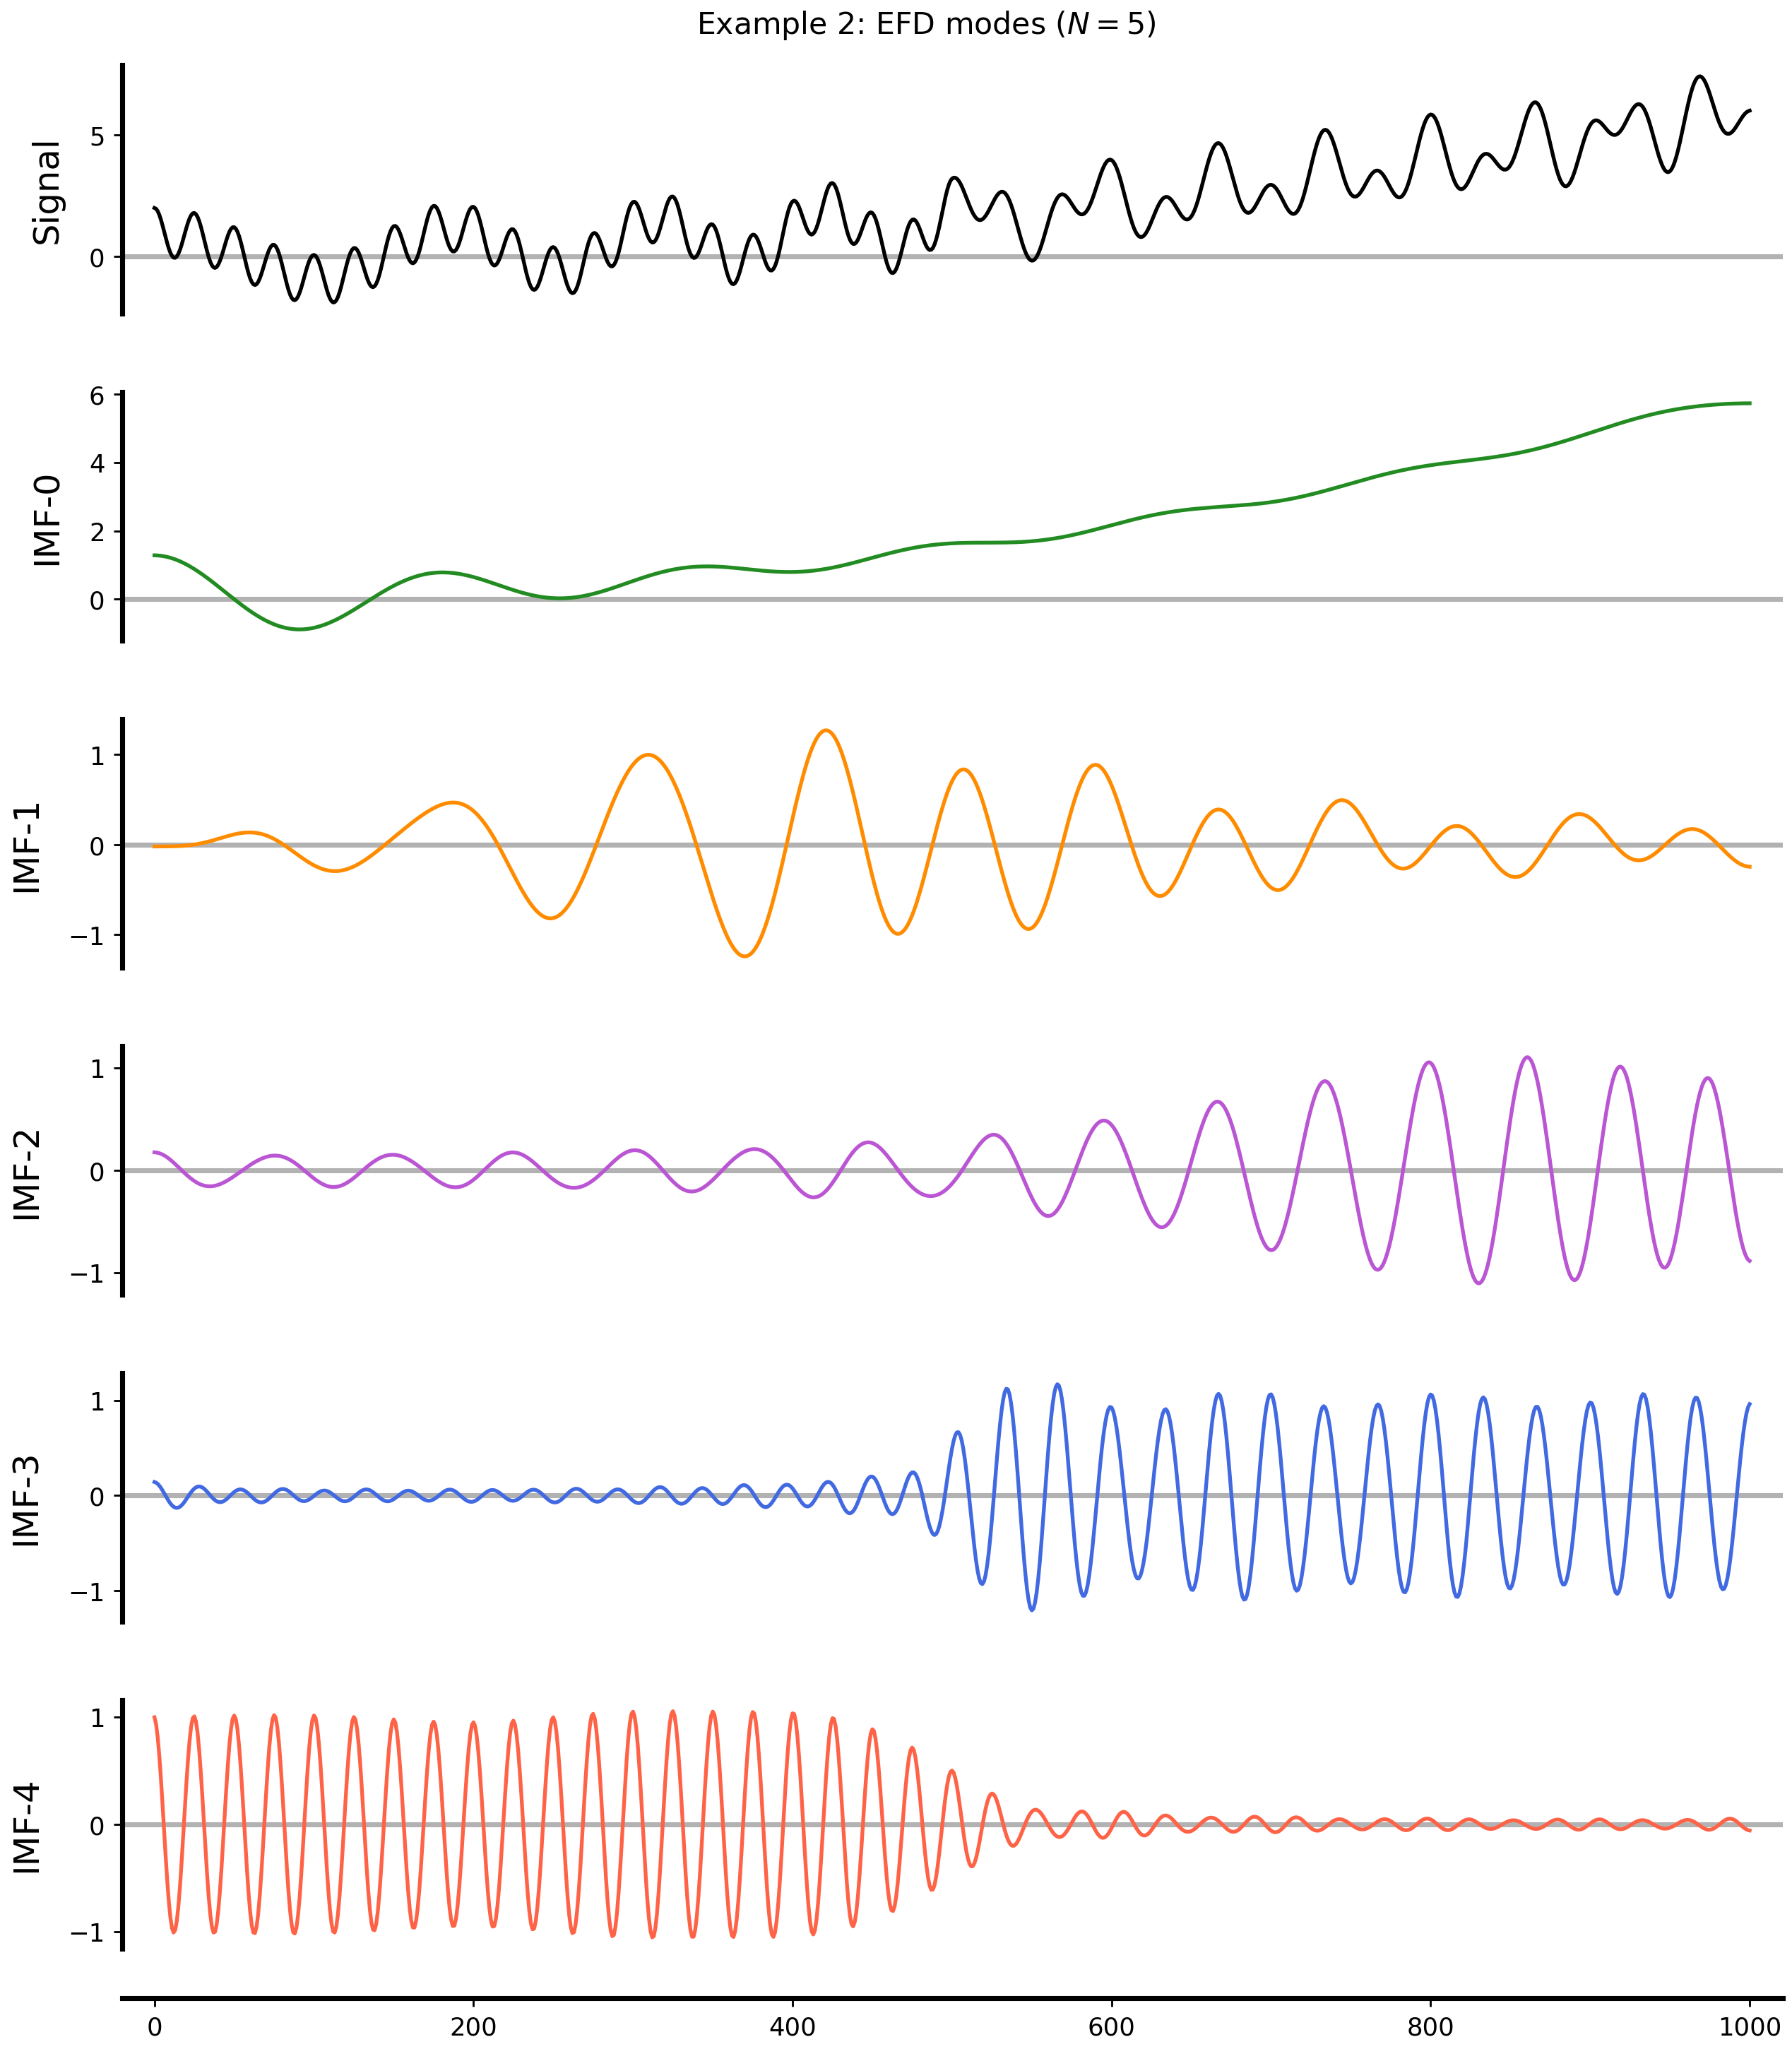

In [5]:
f21 = 6.0 * t**2
f22 = np.cos(8.0 * np.pi * t + 15.0 * np.pi * t**2)
f23 = np.where(t <= 0.5, np.cos(80.0 * np.pi * t), np.cos(60.0 * np.pi * t))
f2 = f21 + f22 + f23

imfs_2, cerf_2, bounds_2 = EFD(max_imfs=5).fit_transform(f2, return_all=True)
print("IMF shape:", imfs_2.shape)
print("boundaries (rad):", np.round(bounds_2, 4))

fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
axes[0].plot(t, f2, color="k")
axes[0].set_ylabel(r"$f_2(t)$")
for ax, y, lab in zip(
    axes[1:], (f21, f22, f23), (r"$f_{21}$", r"$f_{22}$", r"$f_{23}$")
):
    ax.plot(t, y)
    ax.set_ylabel(lab)
axes[-1].set_xlabel("t (s)")
fig.suptitle("Example 2: components (Zhou et al., Fig. 7)")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.5))
plot_bounds(f2, bounds_2, ax=ax)
ax.set_title("Example 2: EFD spectrum boundaries")
fig.tight_layout()
plt.show()

plot_IMFs(f2, imfs_2, fs=fs)
plt.gcf().suptitle("Example 2: EFD modes ($N=5$)", y=1.01)
plt.show()

### 3.3 Example 3 — intra-wave AM–FM (Eq. 24)

This is the Duffing-like pair used by Gilles (EWT) and Dragomiretskiy (VMD):

$$
\begin{aligned}
f_{31}(t)&=\frac{1}{1.2+\cos(2\pi t)},\\
f_{32}(t)&=\bigl(1.2+\sin(2\pi t)\bigr)
\cos\bigl(32\pi t+0.2\cos(64\pi t)\bigr),\\
f_3(t)&=f_{31}(t)+f_{32}(t).
\end{aligned}
$$

The paper sets **3** EFD segments.  The first mode should capture the slow
AM envelope $f_{31}$; the next mode the intra-wave FM oscillator.


IMF shape: (3, 1001)
boundaries (rad): [0.     0.069  0.2257 3.1353]


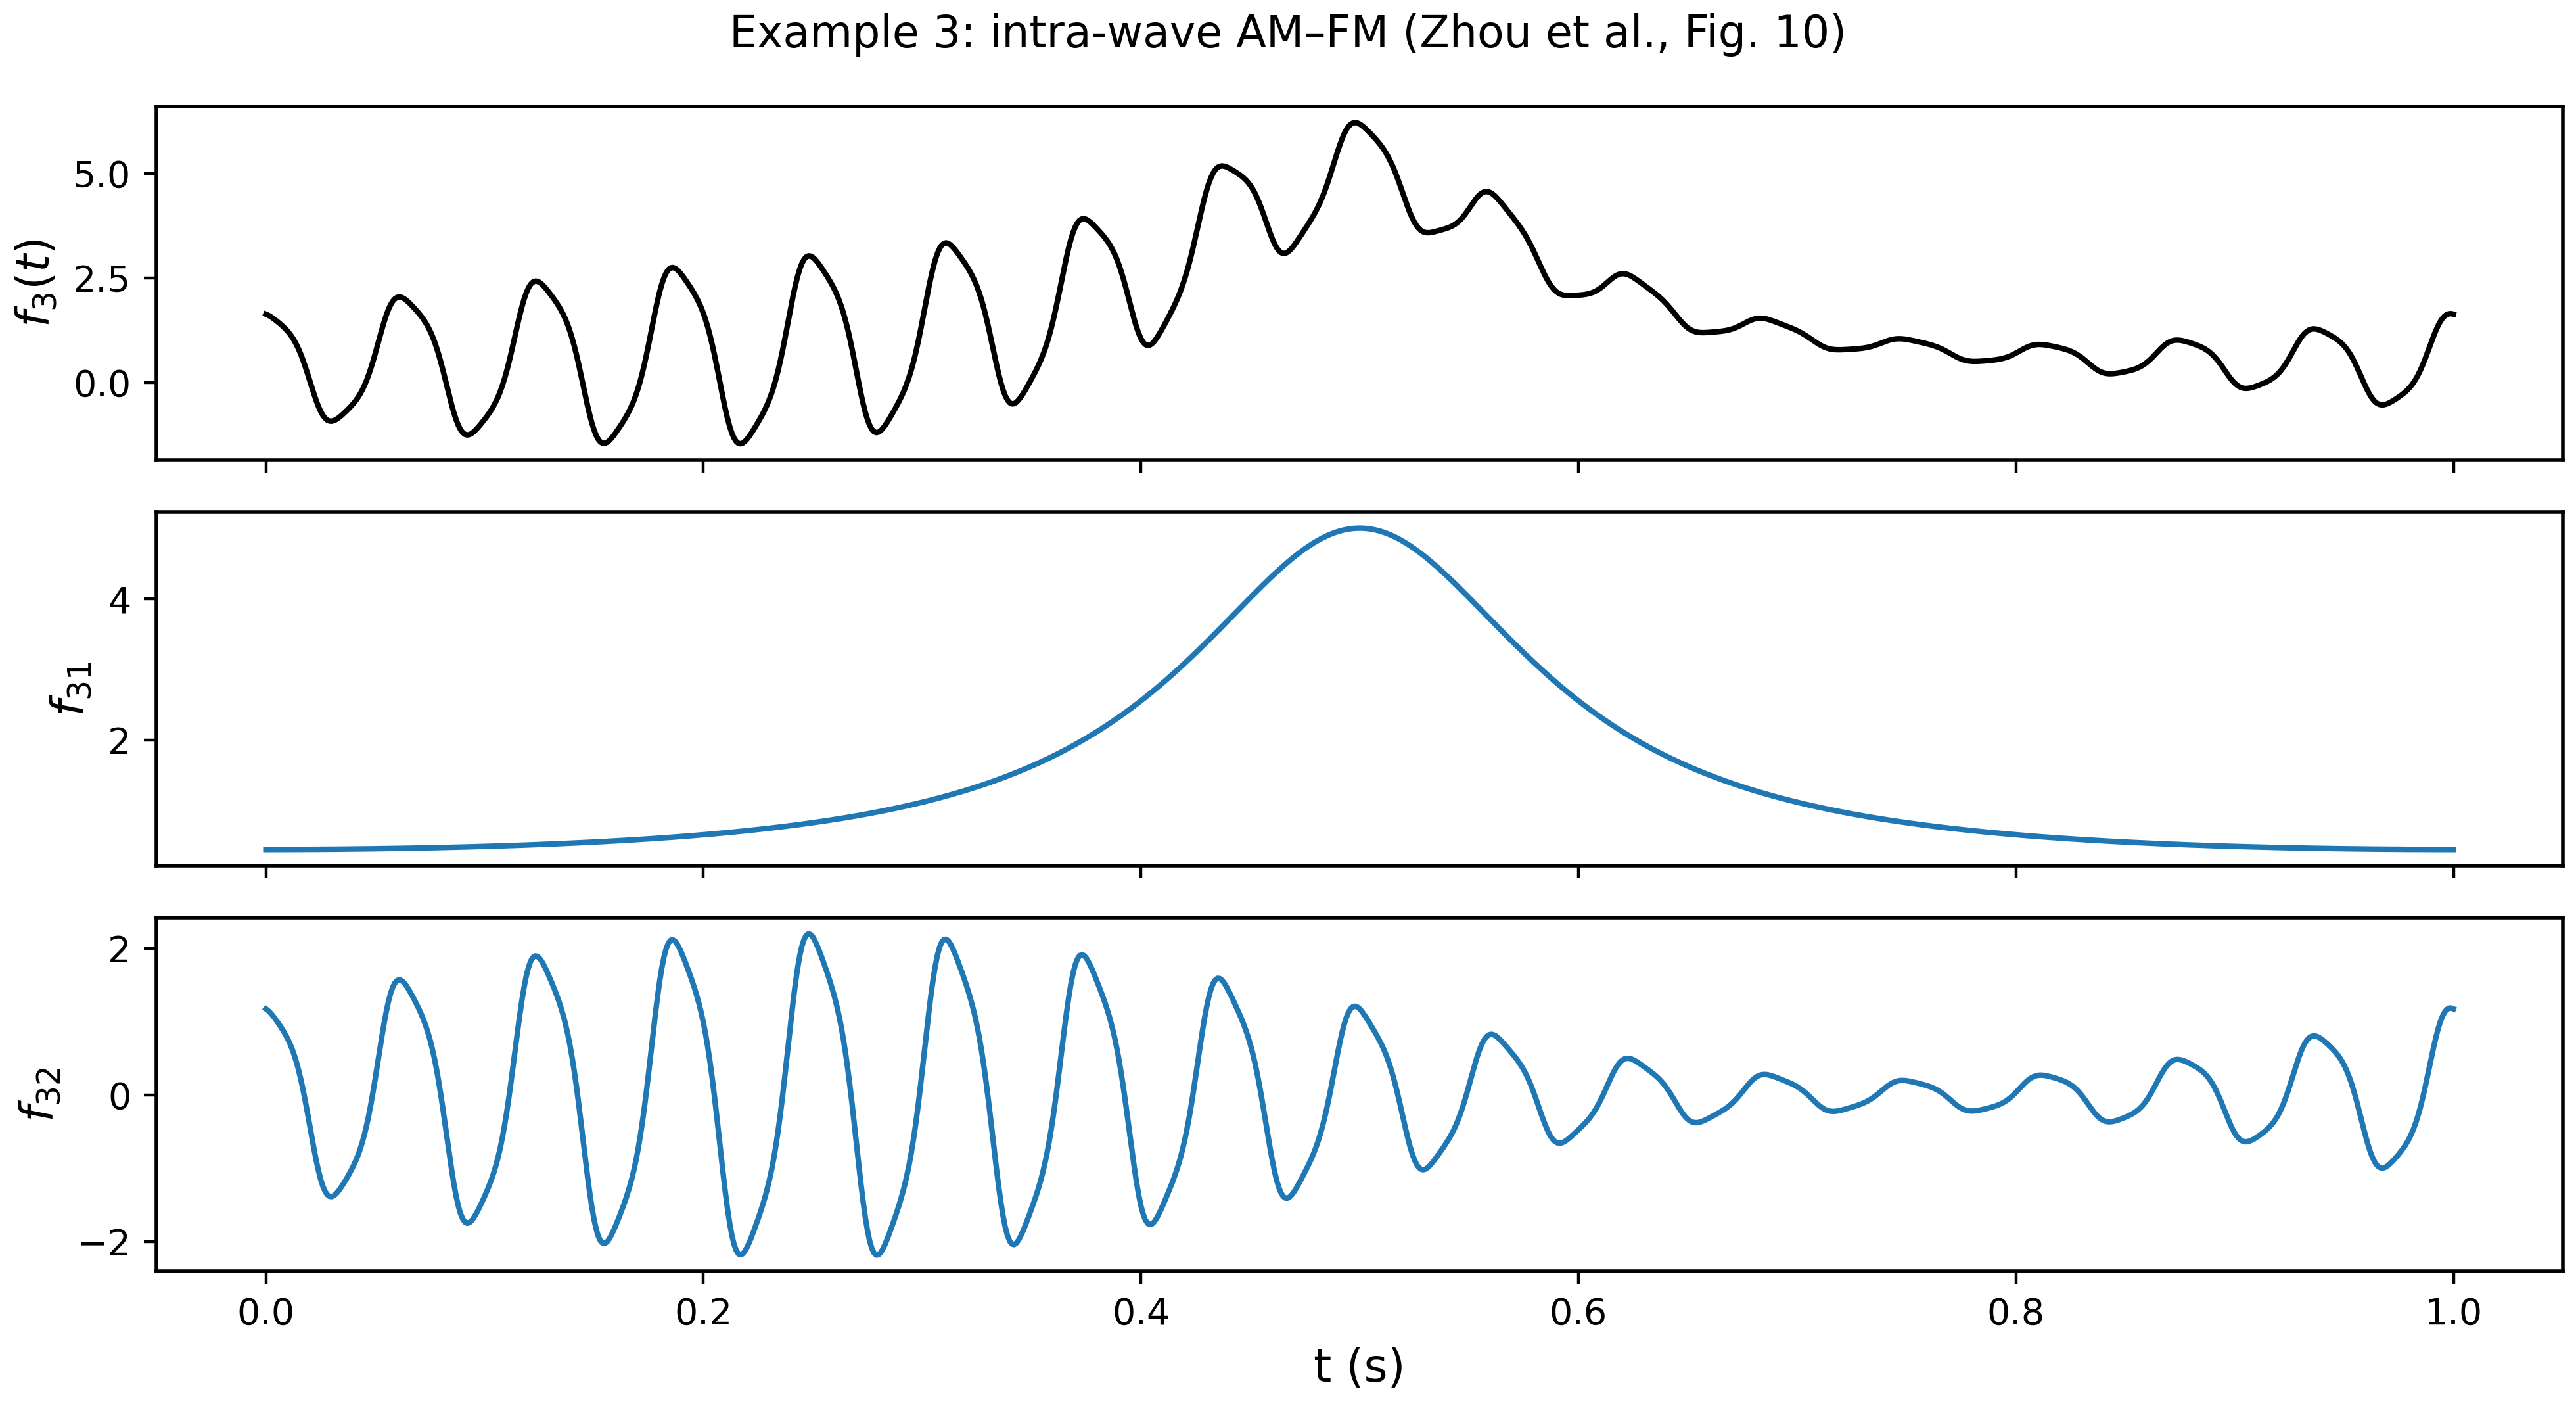

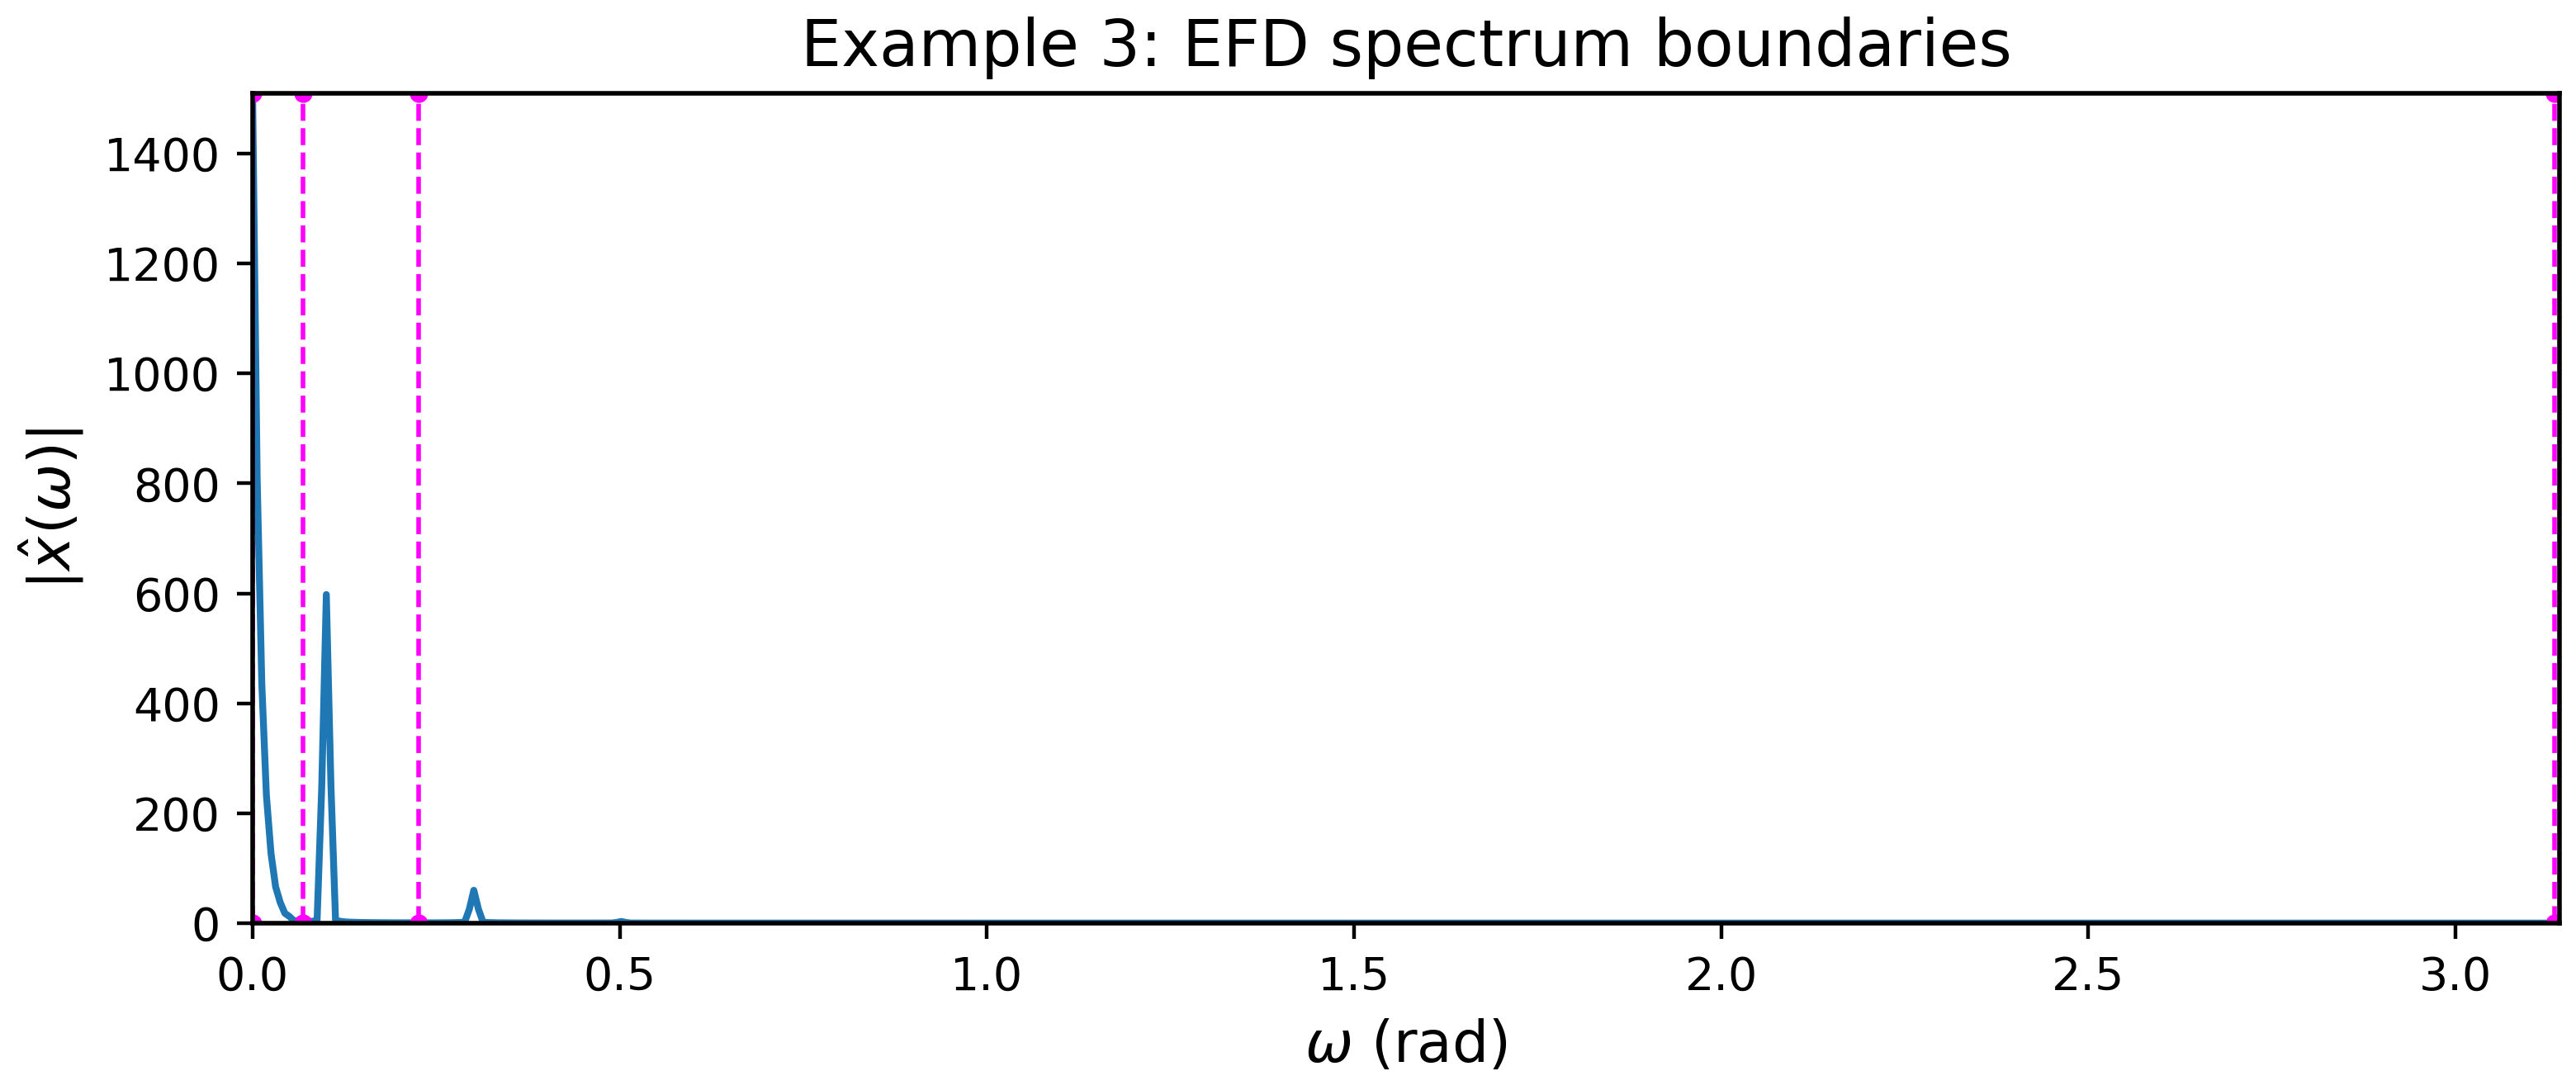

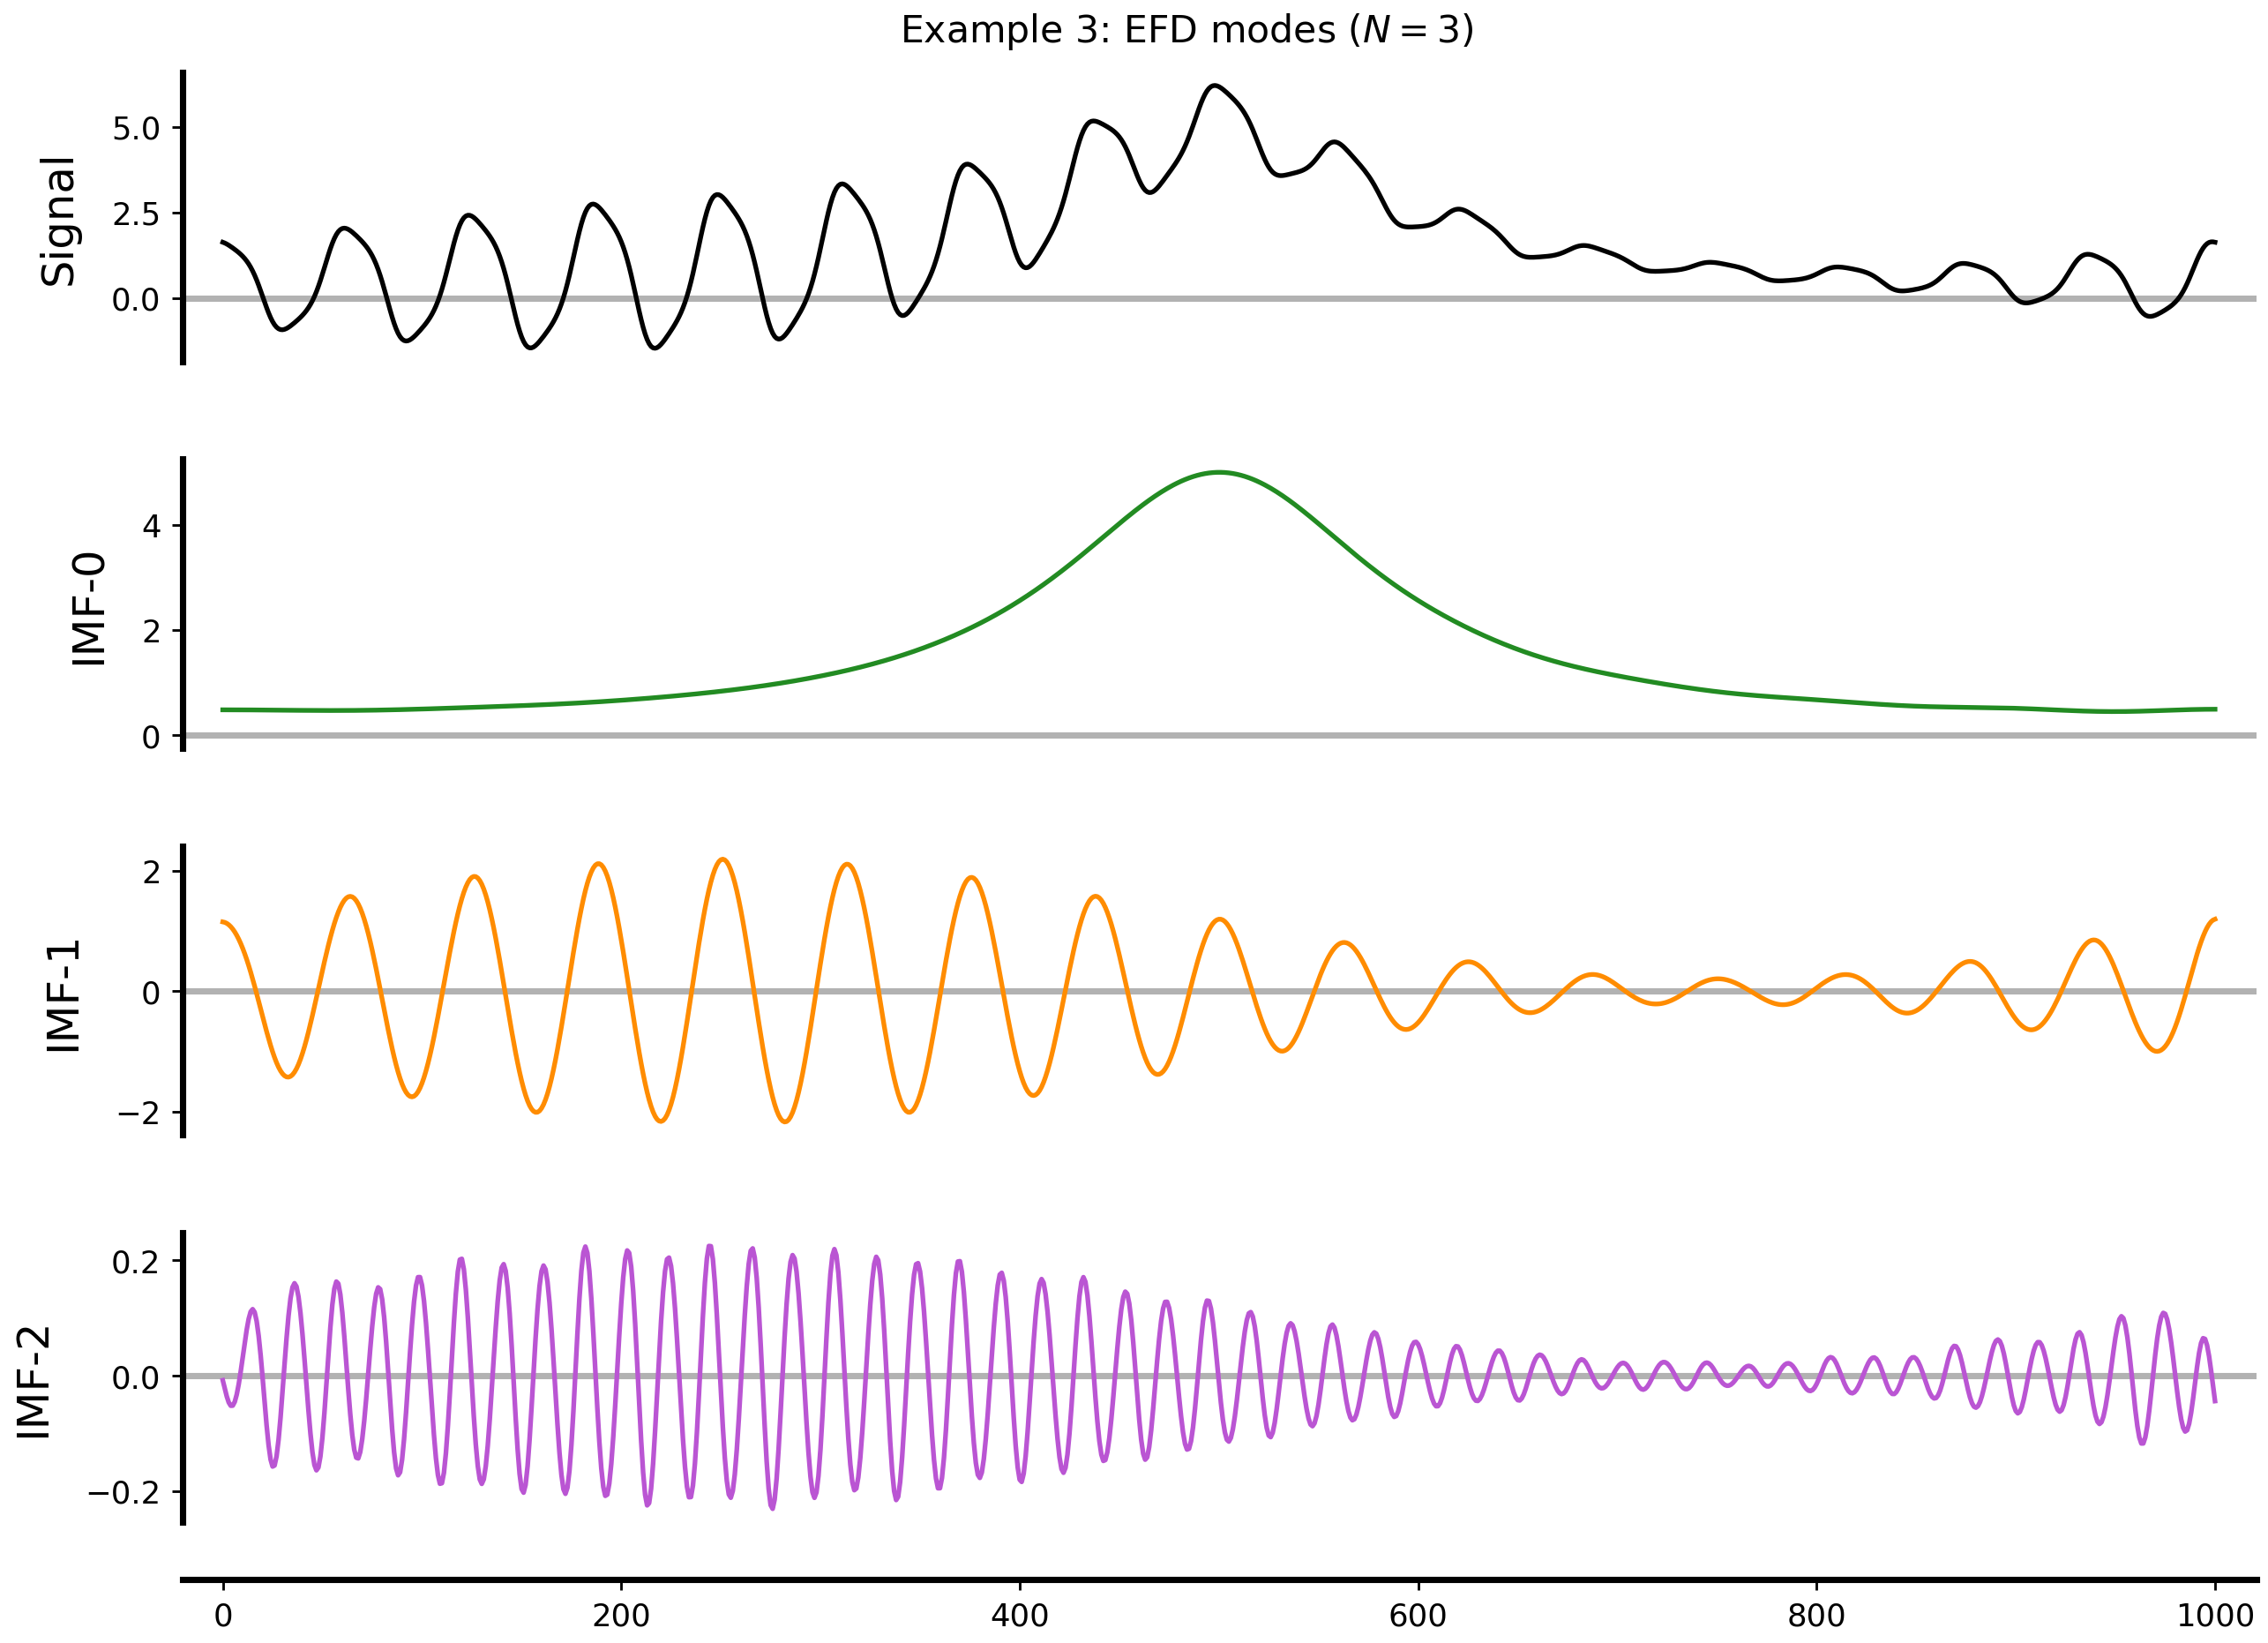

In [6]:
f31 = 1.0 / (1.2 + np.cos(2.0 * np.pi * t))
f32 = (1.2 + np.sin(2.0 * np.pi * t)) * np.cos(
    32.0 * np.pi * t + 0.2 * np.cos(64.0 * np.pi * t)
)
f3 = f31 + f32

imfs_3, cerf_3, bounds_3 = EFD(max_imfs=3).fit_transform(f3, return_all=True)
print("IMF shape:", imfs_3.shape)
print("boundaries (rad):", np.round(bounds_3, 4))

fig, axes = plt.subplots(3, 1, figsize=(10, 5.5), sharex=True)
axes[0].plot(t, f3, color="k")
axes[0].set_ylabel(r"$f_3(t)$")
axes[1].plot(t, f31)
axes[1].set_ylabel(r"$f_{31}$")
axes[2].plot(t, f32)
axes[2].set_ylabel(r"$f_{32}$")
axes[-1].set_xlabel("t (s)")
fig.suptitle("Example 3: intra-wave AM–FM (Zhou et al., Fig. 10)")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.5))
plot_bounds(f3, bounds_3, ax=ax)
ax.set_title("Example 3: EFD spectrum boundaries")
fig.tight_layout()
plt.show()

plot_IMFs(f3, imfs_3, fs=fs)
plt.gcf().suptitle("Example 3: EFD modes ($N=3$)", y=1.01)
plt.show()

Hilbert instantaneous frequency of the oscillatory mode (MATLAB `IFIA.m`,
paper §3.4) should oscillate around 16 Hz with the intra-wave perturbation
$0.2\cos(64\pi t)$.


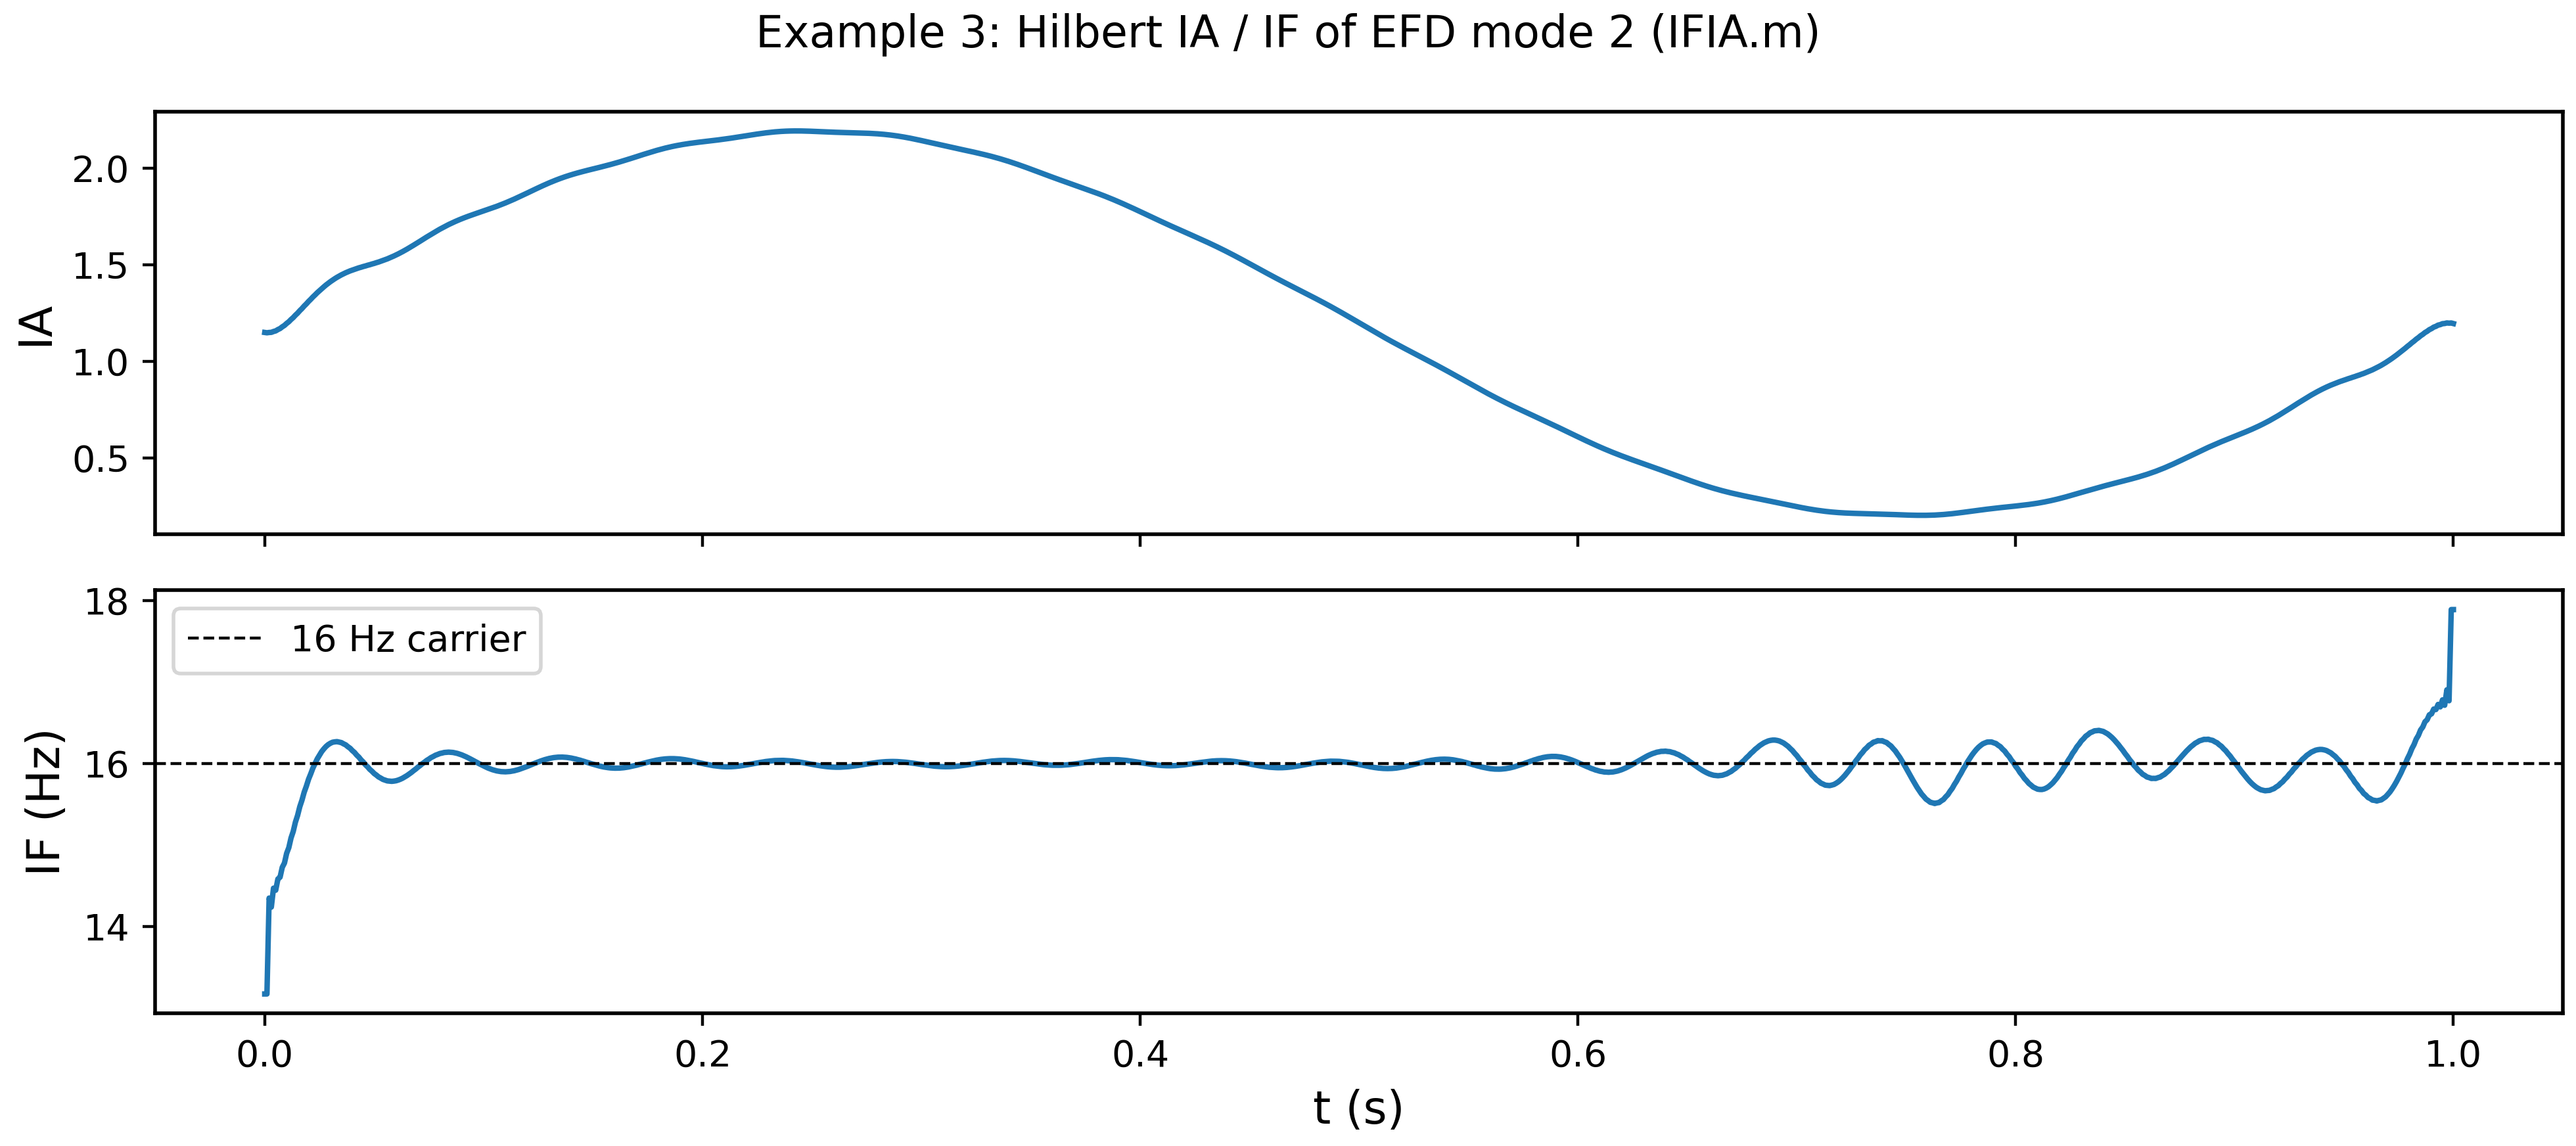

In [7]:
# Pick the IMF that best matches f32
idx_fm = int(
    np.argmax([abs(np.corrcoef(imfs_3[k], f32)[0, 1]) for k in range(imfs_3.shape[0])])
)
inst_freq, inst_amp = ifia(imfs_3[idx_fm], fs)

fig, axes = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True)
axes[0].plot(t, inst_amp)
axes[0].set_ylabel("IA")
axes[1].plot(t, inst_freq)
axes[1].axhline(16.0, color="k", ls="--", lw=0.8, label="16 Hz carrier")
axes[1].set_ylabel("IF (Hz)")
axes[1].set_xlabel("t (s)")
axes[1].legend()
fig.suptitle(f"Example 3: Hilbert IA / IF of EFD mode {idx_fm + 1} (IFIA.m)")
fig.tight_layout()
plt.show()

### 3.4 Example 4 — closely spaced damped modes (Eq. 25)

A 3-DOF free-vibration response with two close natural frequencies and 20 dB
Gaussian noise ($f_s=50\,\mathrm{Hz}$, $T=20\,\mathrm{s}$):

$$
s(t)=\sum_{i=1}^{3} A_i e^{-2\pi\zeta_i f_i t}\cos(2\pi f_i t\sqrt{1-\zeta_i^2})+n(t),
$$

with $f=(1.1,1.3,3.1)\,\mathrm{Hz}$, $\zeta=(2\%,1.2\%,0.8\%)$, $A_i=1$,
$\theta_i=0$.  The paper uses **4** EFD segments (three structural modes plus
a noise band).


IMF shape: (4, 1000)
boundaries (rad): [0.0063 0.1508 0.3142 0.421  1.8284]


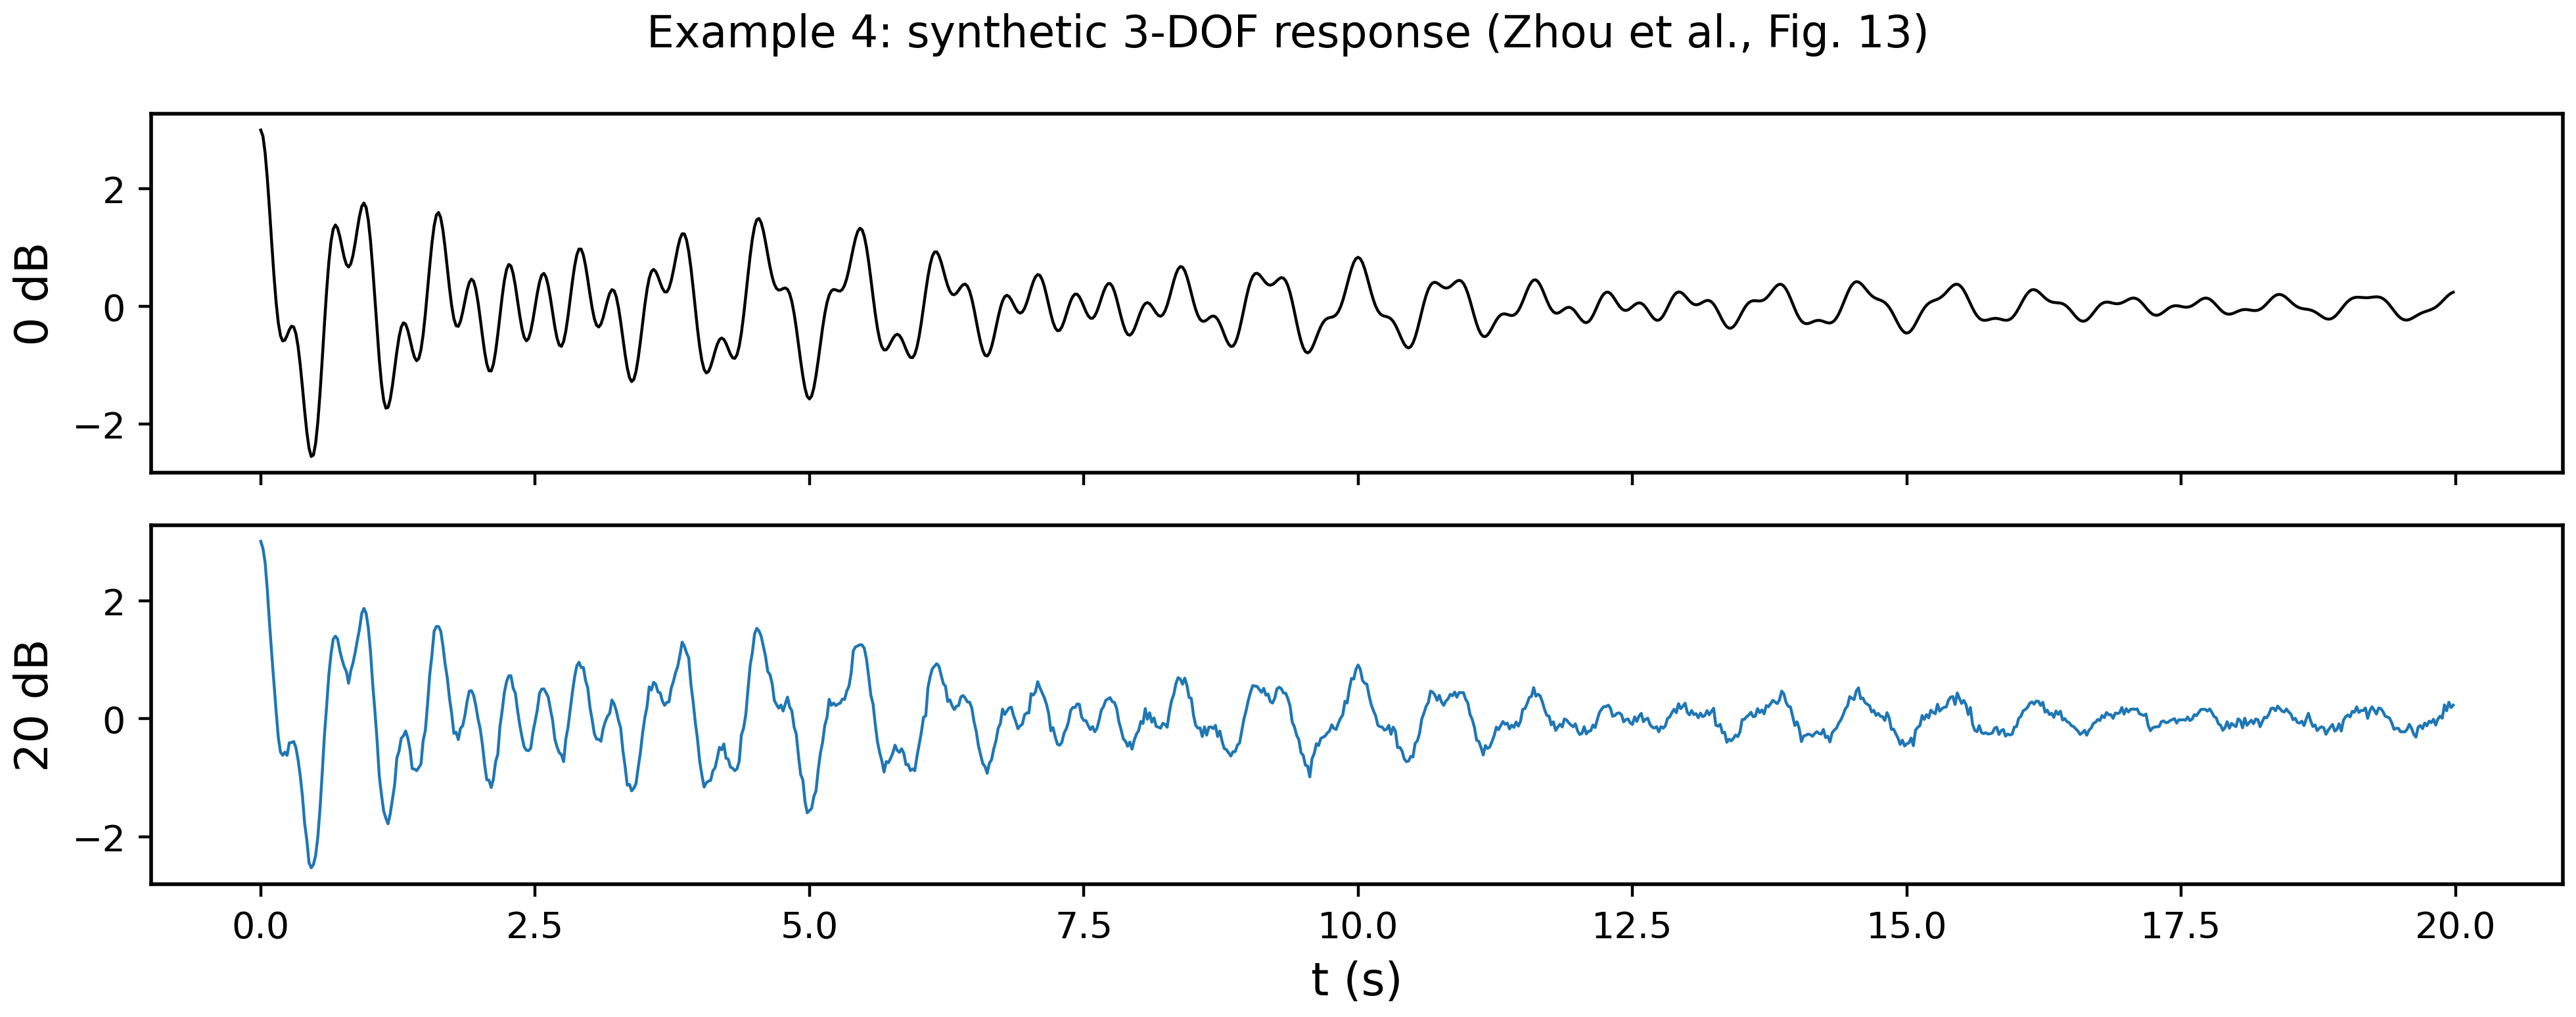

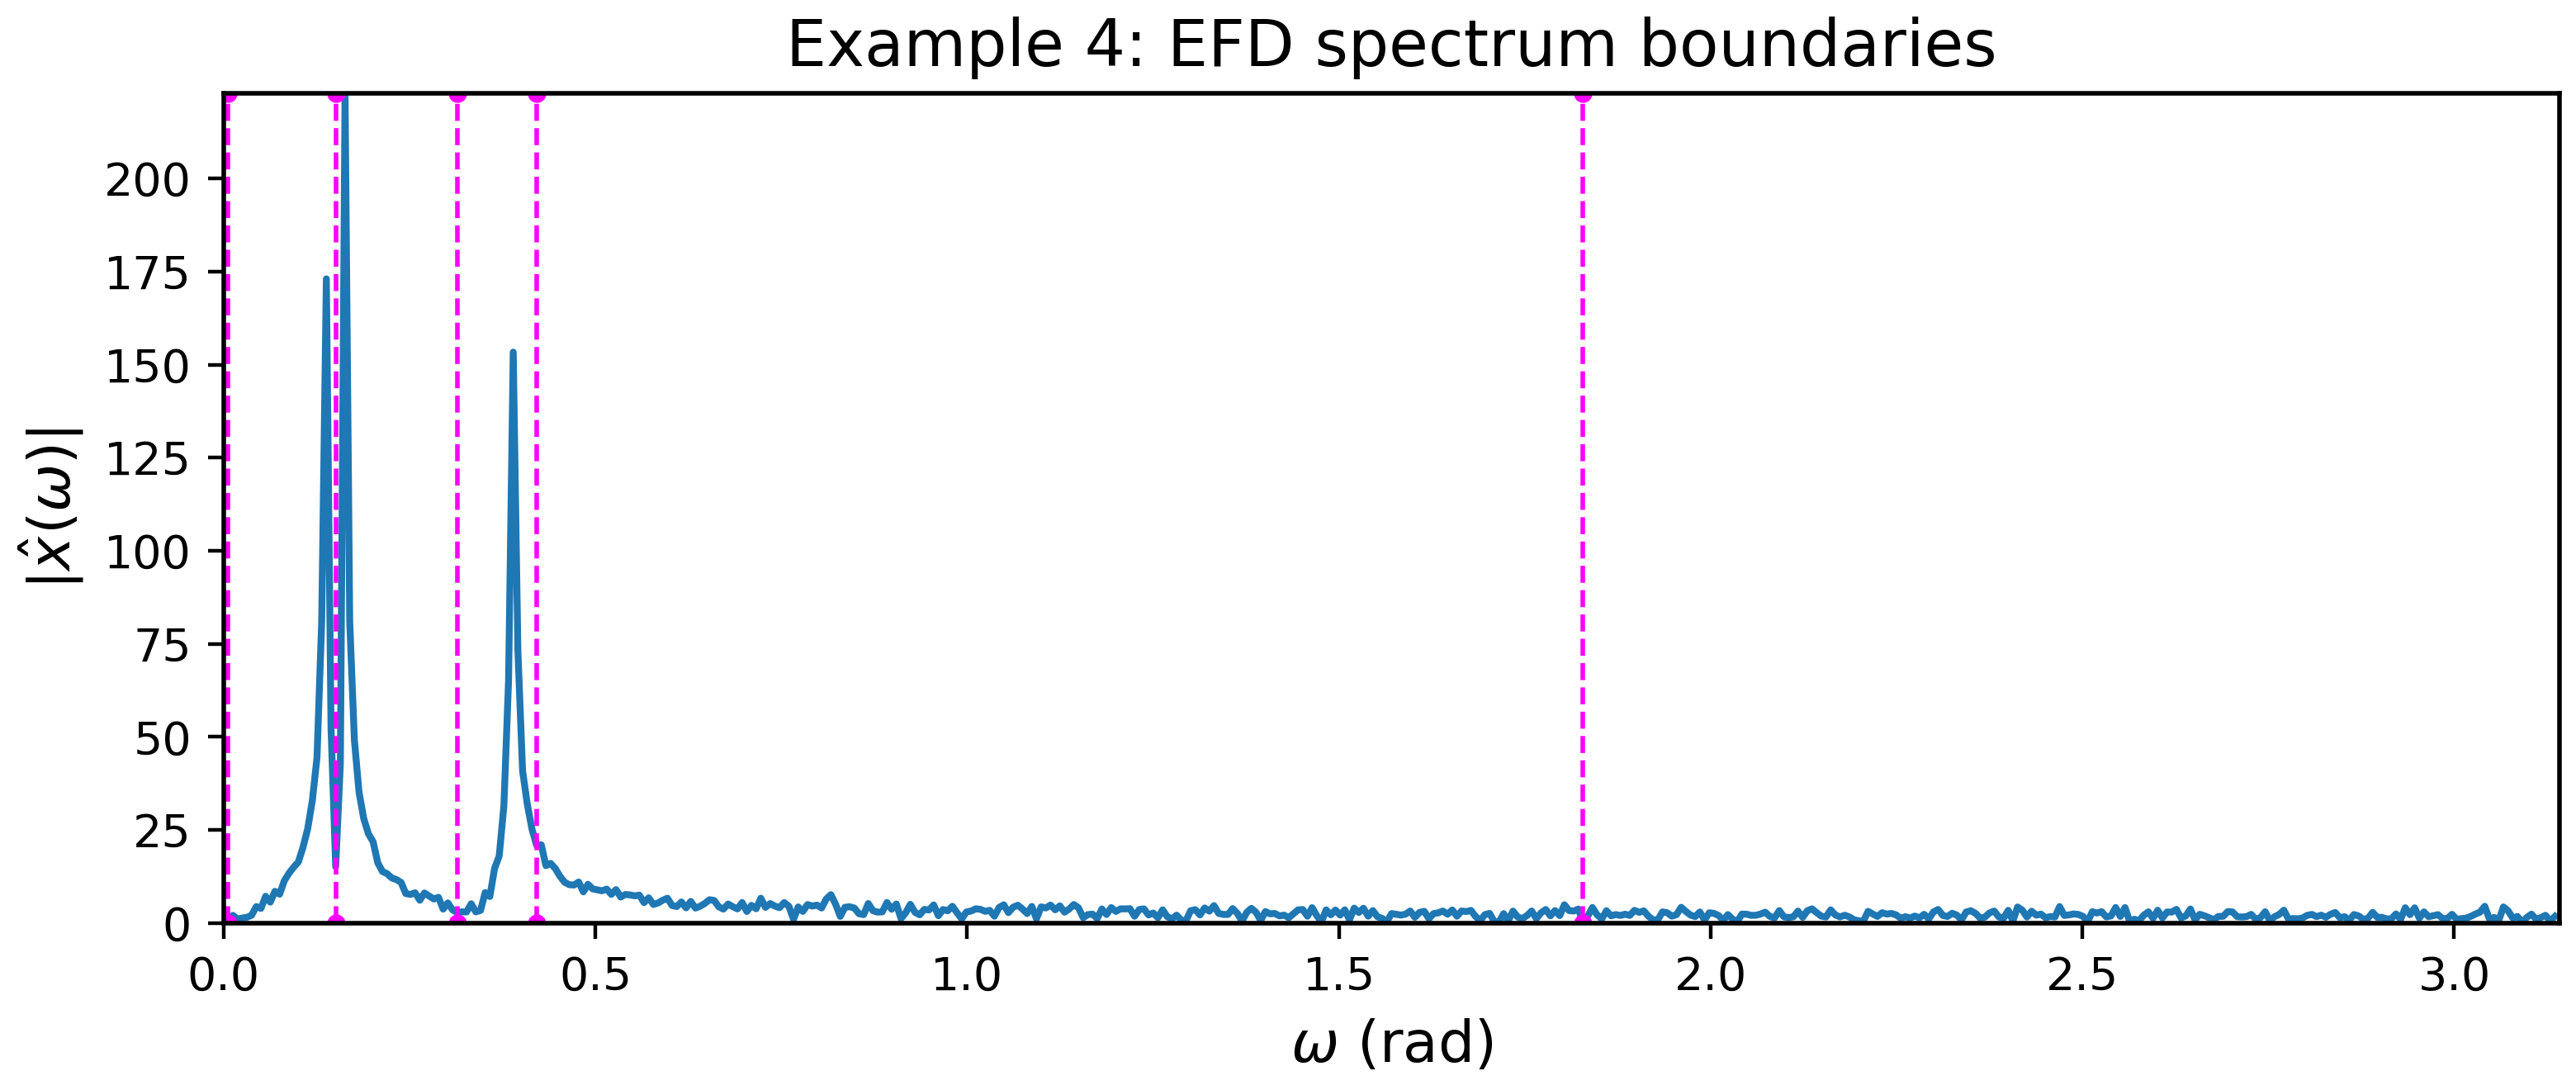

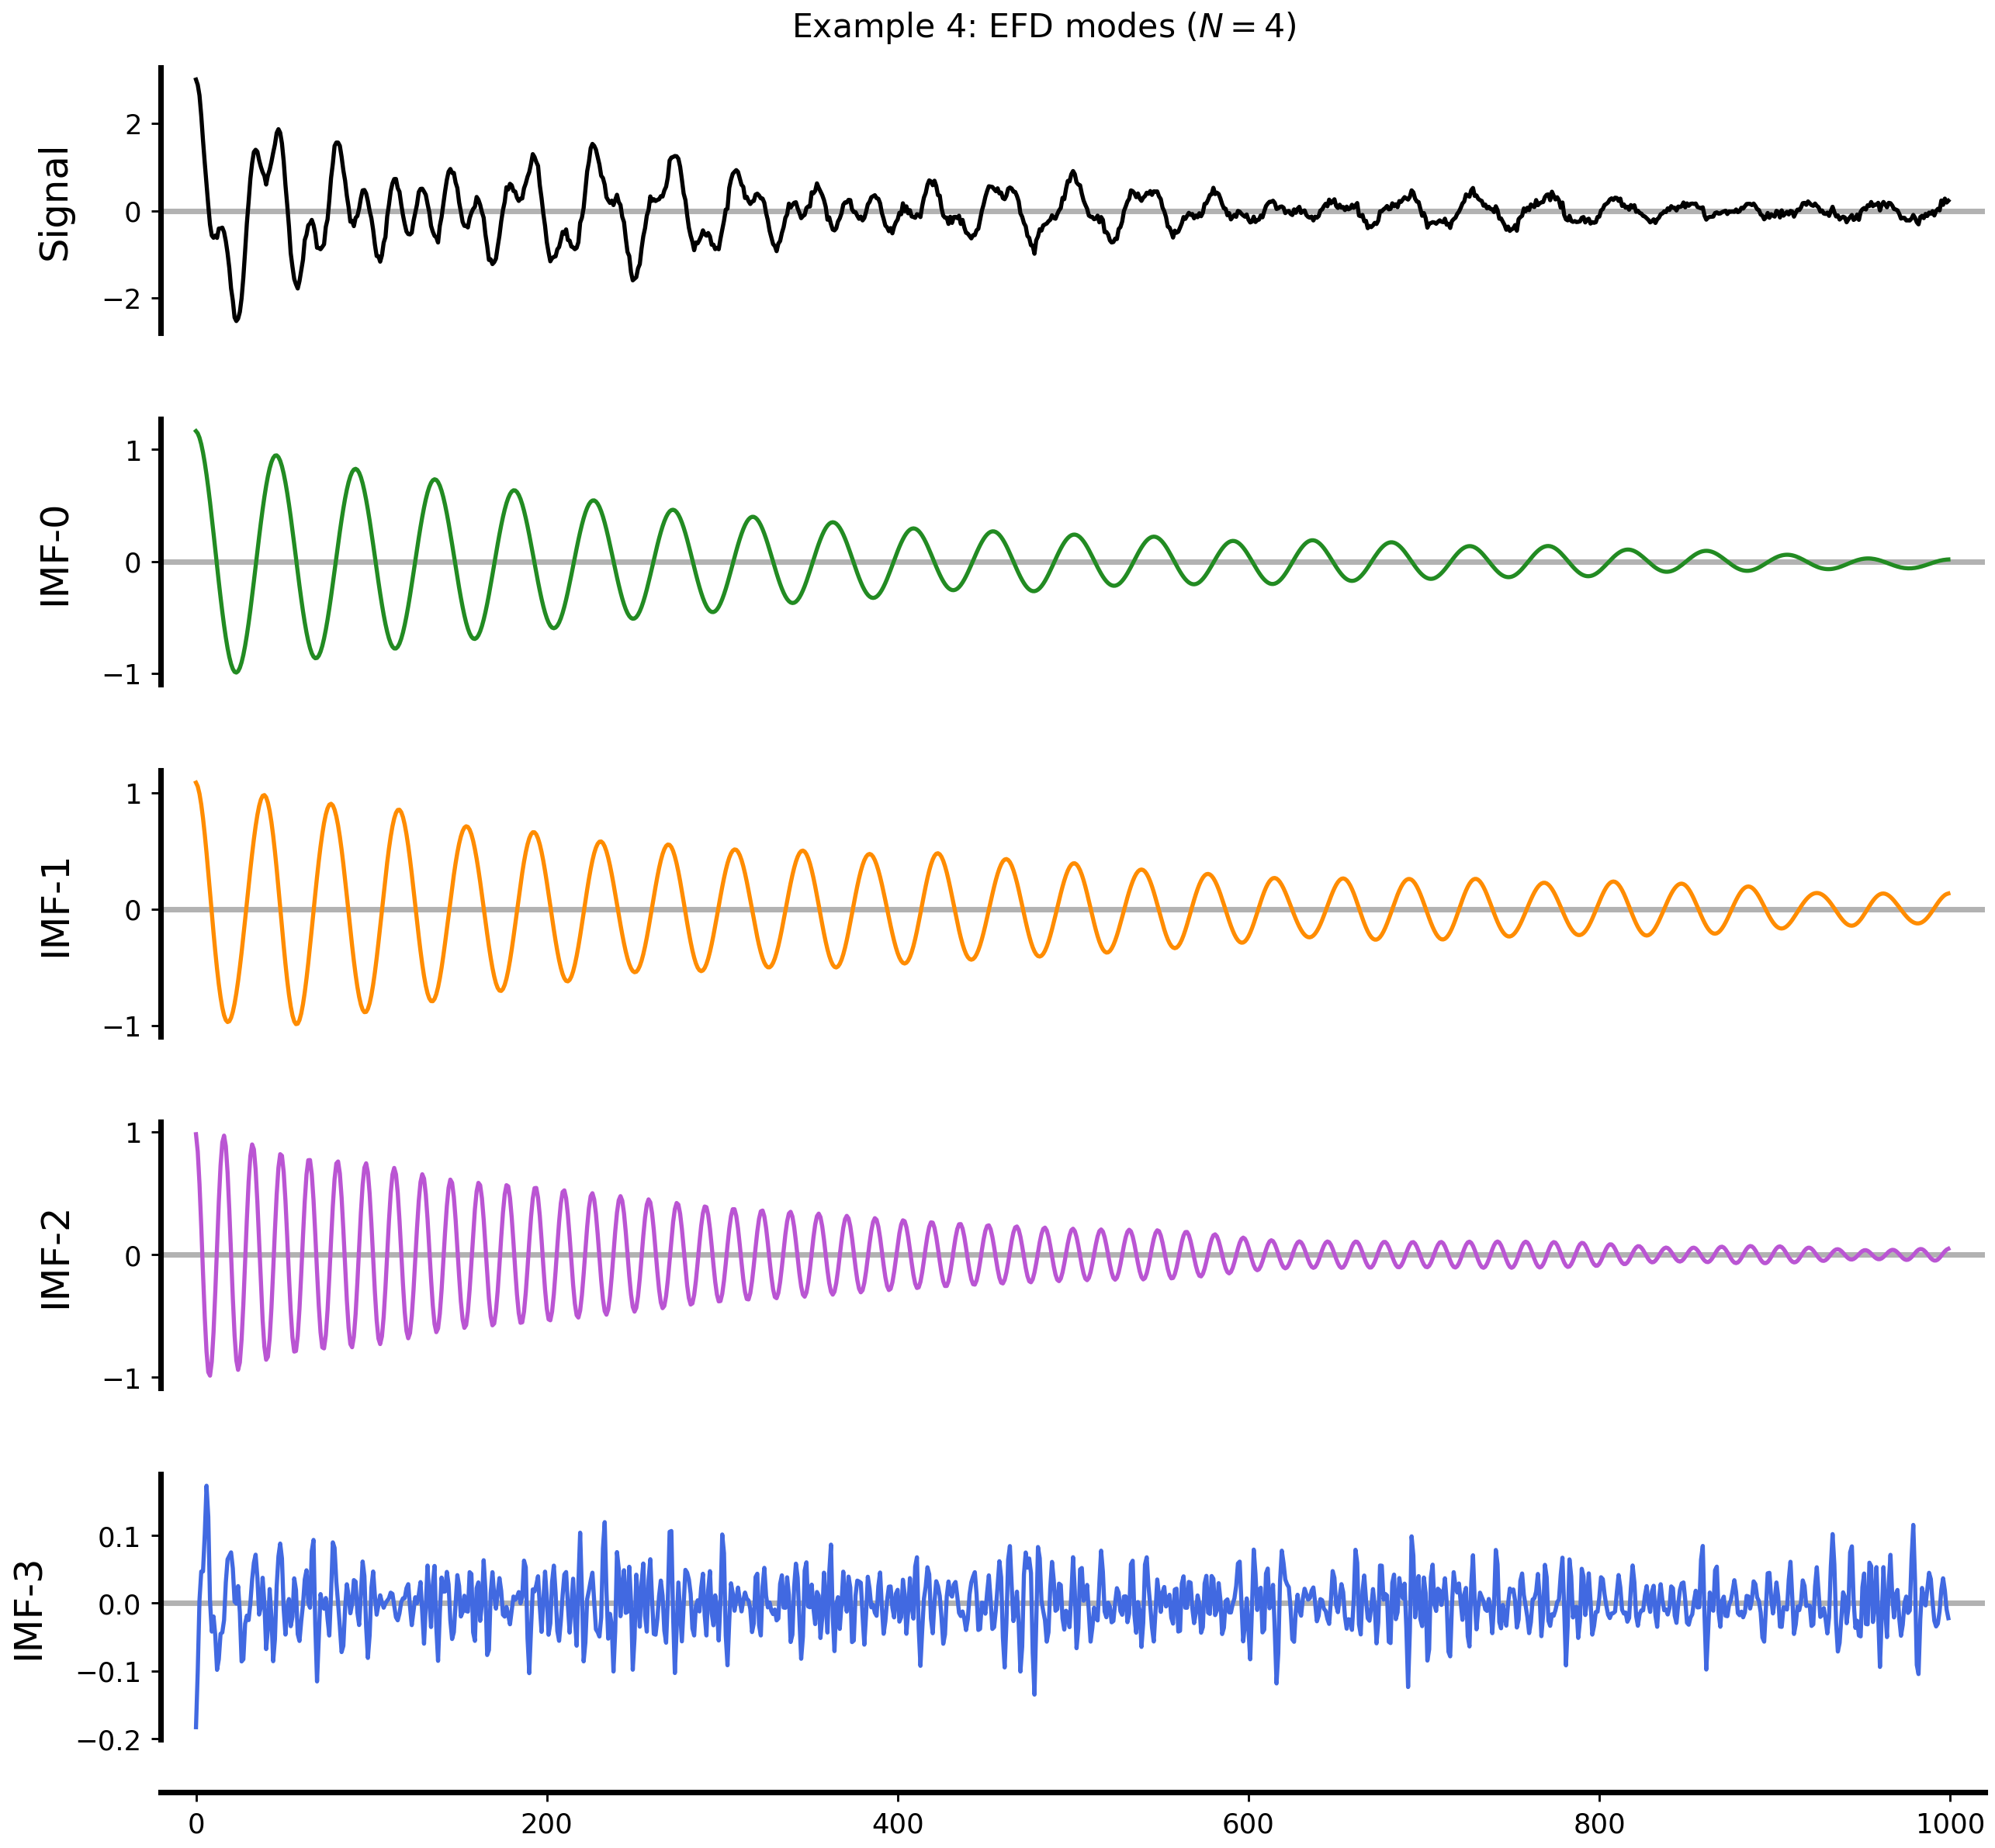

In [8]:
rng = np.random.default_rng(0)
fs4 = 50.0
t4 = np.arange(0.0, 20.0, 1.0 / fs4)
freqs = np.array([1.1, 1.3, 3.1])
zetas = np.array([0.02, 0.012, 0.008])
clean = np.zeros_like(t4)
for fi, zi in zip(freqs, zetas):
    wd = 2.0 * np.pi * fi * np.sqrt(1.0 - zi**2)
    clean += np.exp(-2.0 * np.pi * zi * fi * t4) * np.cos(wd * t4)

noise = rng.normal(size=t4.size)
noise *= np.linalg.norm(clean) / (10.0 * np.linalg.norm(noise))  # ~20 dB
s4 = clean + noise

imfs_4, cerf_4, bounds_4 = EFD(max_imfs=4).fit_transform(s4, return_all=True)
print("IMF shape:", imfs_4.shape)
print("boundaries (rad):", np.round(bounds_4, 4))

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axes[0].plot(t4, clean, color="k", lw=0.8)
axes[0].set_ylabel("0 dB")
axes[1].plot(t4, s4, color="C0", lw=0.8)
axes[1].set_ylabel("20 dB")
axes[1].set_xlabel("t (s)")
fig.suptitle("Example 4: synthetic 3-DOF response (Zhou et al., Fig. 13)")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.5))
plot_bounds(s4, bounds_4, ax=ax)
ax.set_title("Example 4: EFD spectrum boundaries")
fig.tight_layout()
plt.show()

plot_IMFs(s4, imfs_4, fs=fs4)
plt.gcf().suptitle("Example 4: EFD modes ($N=4$)", y=1.01)
plt.show()

## 4. Fourier spectra of the modes

`plot_IMFs_amplitude_spectra` shows that each EFD mode occupies a nearly
rectangular slab of the spectrum — the signature of the ideal filter bank.


run classic


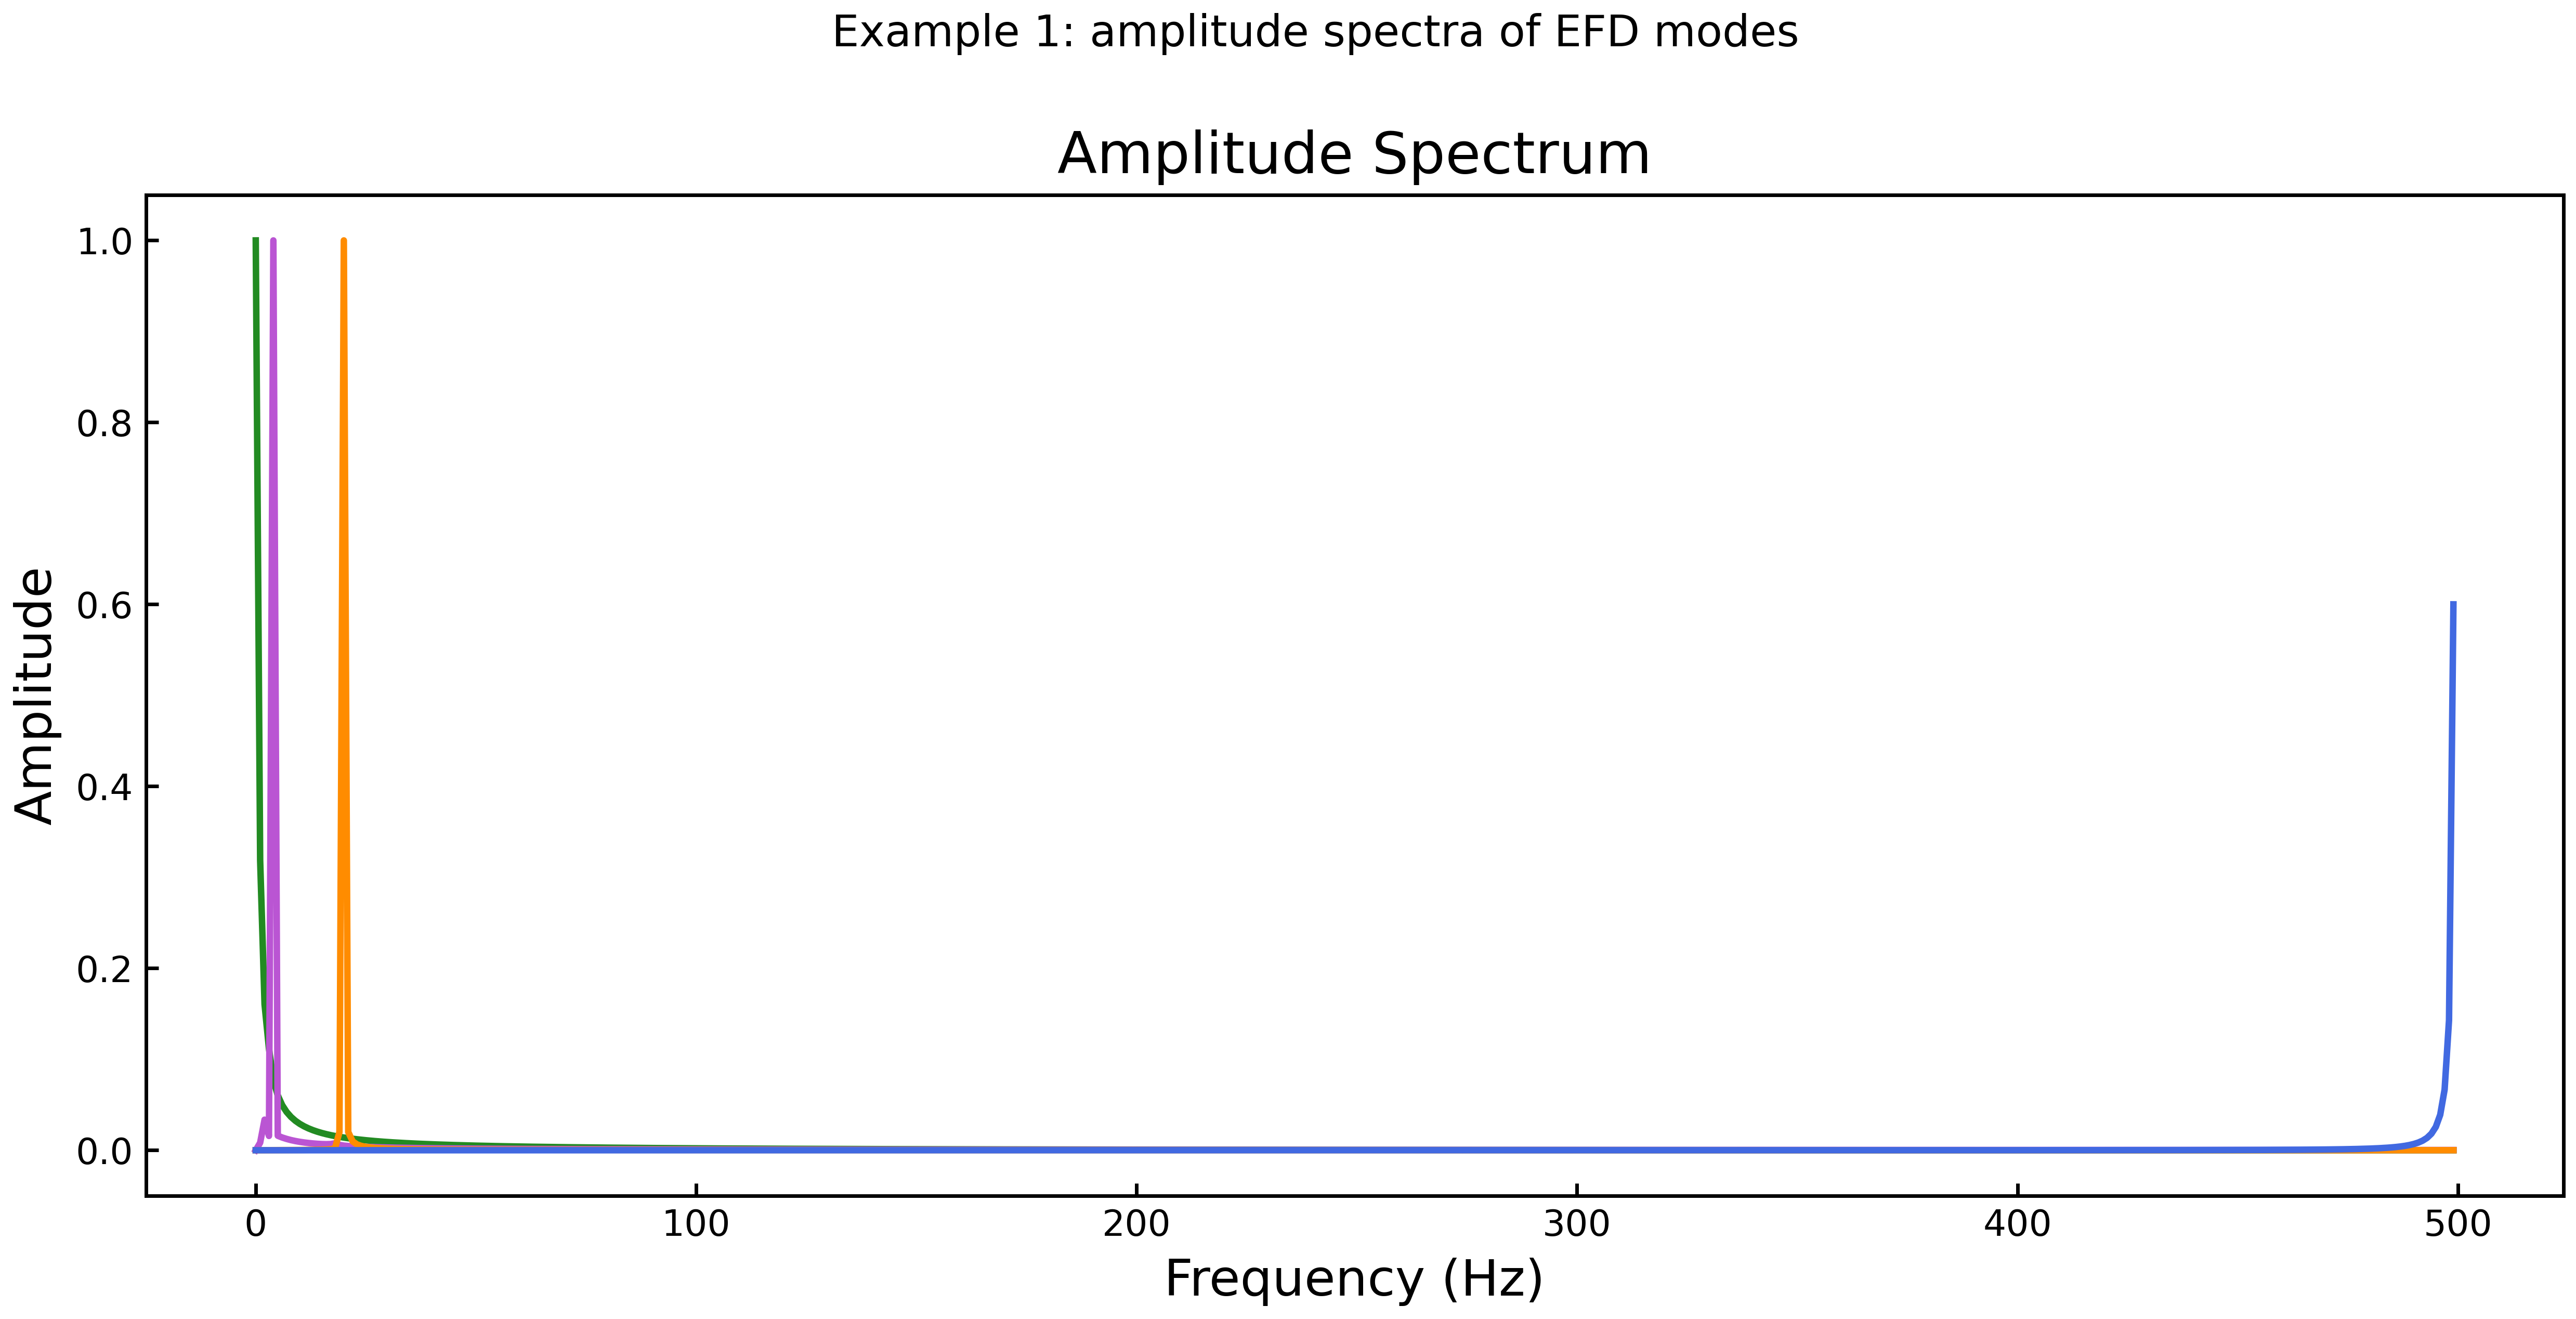

In [9]:
plot_IMFs_amplitude_spectra(imfs_1)
plt.gcf().suptitle("Example 1: amplitude spectra of EFD modes", y=1.02)
plt.show()

## 5. Takeaways

- EFD **does not sift**.  It is an adaptive Fourier filter bank, like EWT,
  and is therefore implemented in `pysdkit._ewt`.
- Segmentation is “$N$ highest maxima $\to$ minimum between them”, which
  the paper argues is more consistent than EWT's midpoint rule for
  low-frequency trends, wide modes, and noise.
- Filters are **ideal and zero-phase** (no Meyer $\gamma$).  Close tones
  leak less through a transition band, at the cost of a slightly more
  rectangular time ringing and shared boundary bins.
- Usage is the usual scikit-learn style: `EFD(max_imfs=N).fit_transform(x)`,
  or `efd(x, max_imfs=N)`.  `return_all=True` yields `(imfs, cerf, bounds)`
  as in MATLAB `[efd, cerf, bounds]`.
